# Base Station Traffic Spike Prediction

**Dataset:** Shanghai Telecom base station access records, June – November 2014.
Each record is one user session at a base station: user ID, base station coordinates, and session start and end time.

| Section | Content |
|---|---|
| 1 | Environment setup and configuration |
| 2 | Data loading |
| 3 | Data overview |
| 4 | Data cleaning |
| 5 | Clean data export |
| 6 | Hourly station load and spike labels |
| 7 | Exploratory data analysis |
| 8 | Feature engineering |
| 9 | Train / test split (70 / 30) |
| 10 | Feature selection |
| 11 | Feature scaling |
| 12 | Models: persistence, logistic regression, LightGBM |
| 13 | Model evaluation |

## 1. Environment Setup and Configuration

Library imports, display and plotting settings, file paths and all pipeline parameters. Every parameter used later in the notebook is defined here.

In [1]:
# =============================================================================
# Imports
# =============================================================================
import glob
import json
import os
import platform
import re
import time
from concurrent.futures import ThreadPoolExecutor

import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shapely
import sklearn
from IPython.display import display
from shapely.geometry import shape
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler

# =============================================================================
# Display and plotting settings
# =============================================================================
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold', 'axes.titlesize': 12})
COLOR = '#1f4e79'           # primary colour for single-series charts
ACCENT = '#c0392b'          # spikes / thresholds

SEED = 42                   # random seed for sampling in feature selection

# =============================================================================
# Paths
# =============================================================================
RAW_DIR       = 'Data/Raw'                                    # 12 raw half-month Excel files (never modified)
DISTRICT_FILE = 'Data/Reference/shanghai_districts.geojson'   # district boundaries (DataV.GeoAtlas)
CLEAN_DIR     = 'Data/Clean'
CLEAN_FILE    = f'{CLEAN_DIR}/sessions_clean.parquet'         # single clean dataset

N_READ_WORKERS = 6    # parallel threads for reading the raw files

# =============================================================================
# Cleaning parameters
# =============================================================================
STUDY_START  = pd.Timestamp('2014-06-01')     # first day of the study period
STUDY_END    = pd.Timestamp('2014-12-01')     # exclusive upper bound
SHANGHAI_LAT = (30.6, 31.9)                   # geographic bounding box of Shanghai
SHANGHAI_LON = (120.8, 122.2)

# =============================================================================
# District assignment
# =============================================================================
DISTRICT_MAX_DIST_KM = 1.0          # max distance to snap a station lying just outside a boundary
DISTRICT_NAMES = {                  # administrative code -> English district name
    '310101': 'Huangpu',   '310104': 'Xuhui',    '310105': 'Changning', '310106': "Jing'an",
    '310107': 'Putuo',     '310109': 'Hongkou',  '310110': 'Yangpu',    '310112': 'Minhang',
    '310113': 'Baoshan',   '310114': 'Jiading',  '310115': 'Pudong',    '310116': 'Jinshan',
    '310117': 'Songjiang', '310118': 'Qingpu',   '310120': 'Fengxian',  '310151': 'Chongming',
}

# =============================================================================
# Hourly load and spike labels (Section 6)
# =============================================================================
MIN_ACTIVE_DAY_FRAC = 0.5    # keep stations with sessions on >= 50% of study days
SPIKE_WINDOW   = 168         # baseline window: previous 7 days (hours)
SPIKE_K        = 2.0         # spike if load > mean + K * std of the baseline window
SPIKE_MIN_LOAD = 3           # ... and at least this many distinct users in the hour
MAX_MISSING_HOURS = 24       # baseline / weekly windows tolerate up to one missing day (data outage)
OUTAGE_FRACTION = 0.2        # hour is an outage if network sessions < 20% of the typical level for that hour

# Official 2014 public holidays in the study period (State Council holiday schedule, Dec 2013)
HOLIDAYS = pd.to_datetime(
    ['2014-06-01', '2014-06-02']                 # Dragon Boat Festival (31 May - 2 Jun)
    + ['2014-09-06', '2014-09-07', '2014-09-08'] # Mid-Autumn Festival
    + [f'2014-10-0{d}' for d in range(1, 8)]     # National Day Golden Week
)
# Weekend days that were official working days (make-up days for the holidays)
ADJUSTED_WORKDAYS = pd.to_datetime(['2014-09-28', '2014-10-11'])

# Notable events in the test period (Section 13.5): (first day, last day, name, type, location)
EVENTS = [
    ('2014-10-01', '2014-10-07', 'National Day Golden Week', 'Public holiday', 'Nationwide'),
    ('2014-10-05', '2014-10-12', 'Shanghai Rolex Masters (ATP tennis)', 'Special event', 'Qizhong Arena, Minhang'),
    ('2014-10-11', '2014-10-11', 'Make-up working day (Saturday)', 'Adjusted working day', 'Nationwide'),
    ('2014-10-31', '2014-11-02', 'FIA WEC 6 Hours of Shanghai', 'Special event', 'Shanghai International Circuit, Jiading'),
    ('2014-11-02', '2014-11-02', 'Shanghai International Marathon', 'Special event', 'City centre'),
    ('2014-11-04', '2014-11-08', 'China International Industry Fair', 'Special event', 'SNIEC, Pudong'),
    ('2014-11-11', '2014-11-11', "Singles' Day (Double 11) shopping festival", 'Special event', 'Online / nationwide'),
]

# =============================================================================
# Feature engineering (Section 8)
# =============================================================================
N_NEIGHBOURS = 5             # nearest stations used for spatial features
HSS_CAP      = 720           # cap for 'hours since last spike' (30 days)
CITY_CENTRE  = (31.2304, 121.4737)   # People's Square (lat, lon)

# =============================================================================
# Split and feature selection (Sections 9 - 10)
# =============================================================================
TEST_SIZE = 0.30             # 70 / 30 chronological train / test split
VAL_SIZE  = 0.15             # last 15% of training hours -> validation (selection, early stopping, threshold)
SELECTION_K_GRID    = [5, 10, 15, 20, 25, 30, 40]   # feature-set sizes evaluated
SELECTION_TOLERANCE = 0.01   # smallest set within 1% of the best validation PR-AUC is kept

# =============================================================================
# Models (Section 12)
# =============================================================================
# Fixed settings used for feature ranking and the feature-set size search (Section 10)
LGB_BASE_PARAMS = {
    'objective': 'binary', 'metric': 'average_precision', 'learning_rate': 0.1,
    'num_leaves': 63, 'min_child_samples': 200, 'feature_fraction': 0.8,
    'bagging_fraction': 0.8, 'bagging_freq': 1, 'lambda_l2': 1.0, 'seed': SEED, 'verbosity': -1,
}
# Final LightGBM hyperparameters, tuned with Optuna (Section 12.1; set RUN_TUNING = True to re-run)
RUN_TUNING   = False
TUNING_TRIALS = 25
LGB_PARAMS = {
    'objective':         'binary',
    'metric':            'average_precision',   # PR-AUC, suited to the rare positive class
    'learning_rate':     0.03,
    'num_leaves':        35,
    'min_child_samples': 527,                   # minimum rows per leaf (limits overfitting)
    'feature_fraction':  0.828,                 # features sampled per tree
    'bagging_fraction':  0.803,                 # rows sampled per tree
    'bagging_freq':      1,
    'lambda_l1':         1.649,                 # L1 regularisation
    'lambda_l2':         5.388,                 # L2 regularisation
    'min_gain_to_split': 0.361,
    'scale_pos_weight':  1.159,                 # weight of the spike class
    'seed':              SEED,
    'verbosity':         -1,
}
LGB_MAX_ROUNDS     = 4000    # upper limit on boosting rounds
LGB_EARLY_STOPPING = 100     # stop when validation PR-AUC has not improved for 100 rounds
SHAP_SAMPLE_SIZE   = 50_000  # test rows used for SHAP feature contributions

print(f'Python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} '
      f'| scikit-learn {sklearn.__version__} | lightgbm {lgb.__version__}')

Python 3.12.3 | pandas 2.2.2 | numpy 2.2.5 | scikit-learn 1.8.0 | lightgbm 4.7.0


## 2. Data Loading

The raw data comes as 12 half-month Excel files. They are read in parallel with the fast `calamine` Excel engine, kept in chronological order and combined into one DataFrame. The number of records in each file is reported.

In [2]:
def file_sort_key(path):
    # (month, start_day) parsed from a file name such as data_6.1~6.15.xlsx
    month, day = re.search(r'data_(\d+)\.(\d+)~', os.path.basename(path)).groups()
    return int(month), int(day)


def read_file(path):
    # calamine (Rust-based) reader: ~3-4x faster than the default openpyxl engine
    return pd.read_excel(path, engine='calamine')


files = sorted(glob.glob(os.path.join(RAW_DIR, '*.xlsx')), key=file_sort_key)

# Read the files in parallel; map() keeps the chronological order
t0 = time.time()
with ThreadPoolExecutor(max_workers=N_READ_WORKERS) as pool:
    frames = list(pool.map(read_file, files))

file_summary = [{
    'File': os.path.basename(f),
    'Records': len(part),
    'First session': part['start time'].min(),
    'Last session': part['start time'].max(),
} for f, part in zip(files, frames)]

df = pd.concat(frames, ignore_index=True)
del frames

file_summary = pd.DataFrame(file_summary)
file_summary.index = range(1, len(file_summary) + 1)

print(f'Files loaded  : {len(files)}')
print(f'Total records : {len(df):,}')
print(f'Loading time  : {time.time() - t0:.1f} s')
display(file_summary.style.format({'Records': '{:,}'}).set_caption('Table 1. Raw data files'))

Files loaded  : 12
Total records : 6,952,921
Loading time  : 96.1 s


,File,Records,First session,Last session
1,data_6.1~6.15.xlsx,"611,506",2014-05-31 23:00:00,2014-06-15 23:58:47
2,data_6.16~6.30.xlsx,"617,629",2014-06-15 21:01:39,2014-06-30 23:04:23
3,data_7.1~7.15.xlsx,"620,830",2014-06-30 18:41:29,2014-07-15 23:51:50
4,data_7.16~7.31.xlsx,"635,362",2014-07-15 22:26:57,2014-07-31 22:25:27
5,data_8.1~8.15.xlsx,"590,585",2014-07-31 19:20:55,2014-08-15 23:45:07
6,data_8.16~8.31.xlsx,"591,942",2014-08-01 09:36:11,2014-08-31 23:48:03
7,data_9.1~9.15.xlsx,"562,779",2014-08-31 21:39:33,2014-09-15 23:49:00
8,data_9.16~9.30.xlsx,"573,139",2014-08-19 23:00:02,2014-09-30 23:48:39
9,data_10.1~10.15.xlsx,"464,572",2014-09-30 22:57:19,2014-10-15 23:49:40
10,data_10.16~10.31.xlsx,"577,102",2014-10-15 21:59:42,2014-10-31 23:57:49


## 3. Data Overview

Structure of the combined raw data: dimensions, a profile of each column (type, non-null and missing counts, unique values), a preview of the records and descriptive statistics.

In [3]:
# =============================================================================
# Dimensions
# =============================================================================
print(f'Records : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB')

# =============================================================================
# Column profile
# =============================================================================
column_profile = pd.DataFrame({
    'Data type': df.dtypes.astype(str),
    'Non-null': df.notna().sum(),
    'Missing': df.isna().sum(),
    'Missing (%)': df.isna().mean() * 100,
    'Unique values': df.nunique(),
})
column_profile.index.name = 'Column'
display(column_profile.style
        .format({'Non-null': '{:,}', 'Missing': '{:,}', 'Missing (%)': '{:.2f}', 'Unique values': '{:,}'})
        .set_caption('Table 2. Column profile of the raw data'))

# =============================================================================
# Record preview
# =============================================================================
display(df.head(10).style.set_caption('Table 3. First 10 records'))
display(df.tail(10).style.set_caption('Table 4. Last 10 records'))

# =============================================================================
# Descriptive statistics (numeric and date-time columns)
# =============================================================================
display(df.describe().T.style
        .format('{:,.4f}', subset=pd.IndexSlice[['latitude', 'longitude'], :])
        .format('{:,.0f}', subset=pd.IndexSlice[['month', 'date'], :])
        .set_caption('Table 5. Descriptive statistics'))

Records : 6,952,921
Columns : 7
Memory  : 855.4 MB


,Data type,Non-null,Missing,Missing (%),Unique values
Column,,,,,
month,int64,"6,952,921",0,0.00,6
date,int64,"6,952,921",0,0.00,31
start time,datetime64[ns],"6,952,921",0,0.00,"5,326,416"
end time,datetime64[ns],"6,952,921",0,0.00,"5,342,942"
latitude,float64,"6,236,620","716,301",10.30,"3,025"
longitude,float64,"6,236,620","716,301",10.30,"3,035"
user id,object,"6,952,921",0,0.00,"9,739"


Column,month,date,start time,end time,latitude,longitude,user id
0,201406,1,2014-06-01 10:22:36,2014-06-01 11:09:52,31.237872,121.470259,edbc54bddf16494a49f39ac057b4185d
1,201406,1,2014-06-01 07:00:37,2014-06-01 08:49:20,31.237872,121.470259,f8206ab58b9bdb070673f7050242e9ee
2,201406,1,2014-06-01 02:49:16,2014-06-01 05:49:12,31.237872,121.470259,f8206ab58b9bdb070673f7050242e9ee
3,201406,1,2014-06-01 08:51:58,2014-06-01 09:20:50,31.237872,121.470259,f8206ab58b9bdb070673f7050242e9ee
4,201406,1,2014-05-31 23:49:10,2014-06-01 02:49:07,31.237872,121.470259,f8206ab58b9bdb070673f7050242e9ee
5,201406,1,2014-05-31 23:39:02,2014-05-31 23:49:05,31.237872,121.470259,f8206ab58b9bdb070673f7050242e9ee
6,201406,1,2014-06-01 17:17:24,2014-06-01 17:18:32,31.237872,121.470259,eb7f2c8f7030376959889a2fae9c3a1d
7,201406,1,2014-06-01 17:17:14,2014-06-01 18:32:29,31.237872,121.470259,eb7f2c8f7030376959889a2fae9c3a1d
8,201406,1,2014-06-01 11:17:02,2014-06-01 11:17:23,31.237872,121.470259,edbc54bddf16494a49f39ac057b4185d
9,201406,1,2014-06-01 10:19:43,2014-06-01 10:20:14,31.237872,121.470259,edbc54bddf16494a49f39ac057b4185d


Column,month,date,start time,end time,latitude,longitude,user id
6952911,201411,30,2014-11-30 05:49:27,2014-11-30 06:33:15,nan,nan,2aa2772a12a1135affd3334961c17811
6952912,201411,30,2014-11-30 07:17:08,2014-11-30 07:39:35,nan,nan,2aa2772a12a1135affd3334961c17811
6952913,201411,30,2014-11-30 20:22:22,2014-11-30 20:46:35,nan,nan,052b6c524b131480b0a4800005cb144e
6952914,201411,30,2014-11-30 20:17:49,2014-11-30 20:17:56,nan,nan,052b6c524b131480b0a4800005cb144e
6952915,201411,30,2014-11-30 17:20:32,2014-11-30 17:20:34,nan,nan,ec22557eed4761b9428bf9fe390292cb
6952916,201411,30,2014-11-30 10:06:19,2014-11-30 10:06:21,nan,nan,ec22557eed4761b9428bf9fe390292cb
6952917,201411,30,2014-11-30 13:02:19,2014-11-30 13:02:21,nan,nan,1566134ec7f832b501df944b13b8631a
6952918,201411,30,2014-11-30 21:02:26,2014-11-30 21:04:44,nan,nan,052b6c524b131480b0a4800005cb144e
6952919,201411,30,2014-11-30 20:50:09,2014-11-30 20:52:30,nan,nan,052b6c524b131480b0a4800005cb144e
6952920,201411,30,2014-11-30 20:58:46,2014-11-30 20:59:50,nan,nan,052b6c524b131480b0a4800005cb144e


,count,mean,min,25%,50%,75%,max,std
Column,,,,,,,,
month,"6,952,921","201,408","201,406","201,407","201,408","201,410","201,411",2
date,"6,952,921",16,1,8,16,23,31,9
start time,6952921,2014-08-28 20:21:48.161975296,2014-05-31 23:00:00,2014-07-13 07:44:44,2014-08-26 17:12:12,2014-10-14 13:59:56,2014-11-30 23:56:40,nan
end time,6952921,2014-08-28 21:00:29.251069184,2014-05-31 23:03:20,2014-07-13 08:23:28,2014-08-26 17:50:17,2014-10-14 14:42:54,2014-11-30 23:57:12,nan
latitude,"6,236,620.0000",31.1977,22.5228,31.1178,31.2043,31.2695,47.3509,0.7442
longitude,"6,236,620.0000",121.3191,102.0040,121.3587,121.4384,121.5139,131.8122,1.3865


## 4. Data Cleaning

Cleaning is applied in five steps. The record count is logged after every step:

| Step | Operation |
|---|---|
| 4.1 | Standardise column names and data types, drop the redundant `date` column |
| 4.2 | Remove duplicate records |
| 4.3 | Remove records with missing values |
| 4.4 | Remove invalid records |
| 4.5 | Assign each record to a Shanghai district |

### 4.1 Standardise Column Names and Data Types

Column names are converted to `snake_case`. Time and coordinate columns are converted to their proper types; any value that cannot be converted becomes missing and is removed in step 4.3. The `date` column (day of month of the logging date) is redundant with `start_time` and is dropped.

In [4]:
# Record count after every cleaning step
cleaning_log = []

def log_step(step, rows_before, rows_after):
    removed = rows_before - rows_after
    cleaning_log.append({'Step': step, 'Records before': rows_before,
                         'Removed': removed, 'Records after': rows_after})
    print(f'{step}')
    print(f'  Records before : {rows_before:>12,}')
    print(f'  Removed        : {removed:>12,}  ({removed / rows_before:.3%})')
    print(f'  Records after  : {rows_after:>12,}')


df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
df = df.drop(columns=['date'])

df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df['end_time']   = pd.to_datetime(df['end_time'], errors='coerce')
df['latitude']   = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude']  = pd.to_numeric(df['longitude'], errors='coerce')

cleaning_log.append({'Step': 'Raw combined data', 'Records before': len(df),
                     'Removed': 0, 'Records after': len(df)})

print(f'Total records: {len(df):,}\n')
display(df.dtypes.astype(str).to_frame('Data type').rename_axis('Column')
          .style.set_caption('Table 6. Standardised columns'))

Total records: 6,952,921



,Data type
Column,
month,int64
start_time,datetime64[ns]
end_time,datetime64[ns]
latitude,float64
longitude,float64
user_id,object


### 4.2 Duplicate Records

A record is a duplicate if it is identical to another record in every column. The first occurrence is kept and the copies are removed.

In [5]:
n_before = len(df)
dup_mask = df.duplicated(keep='first')
n_dup = int(dup_mask.sum())

print(f'Total records     : {n_before:,}')
print(f'Duplicate records : {n_dup:,} ({n_dup / n_before:.3%})\n')

display(df[df.duplicated(keep=False)]
          .sort_values(['user_id', 'start_time'])
          .head(10)
          .style.set_caption('Table 7. Examples of duplicate records (each record and its copy)'))

df = df.loc[~dup_mask].reset_index(drop=True)
del dup_mask

print()
log_step('Remove duplicate records', n_before, len(df))

Total records     : 6,952,921
Duplicate records : 2,055 (0.030%)



,month,start_time,end_time,latitude,longitude,user_id
519151,201406,2014-06-13 15:52:49,2014-06-13 15:53:21,31.246345,121.453710,0019e53be51fb4fd951e1a817d8c54ee
519152,201406,2014-06-13 15:52:49,2014-06-13 15:53:21,31.246345,121.453710,0019e53be51fb4fd951e1a817d8c54ee
1796616,201407,2014-07-14 15:14:35,2014-07-14 15:30:10,31.246345,121.453710,0019e53be51fb4fd951e1a817d8c54ee
1796617,201407,2014-07-14 15:14:35,2014-07-14 15:30:10,31.246345,121.453710,0019e53be51fb4fd951e1a817d8c54ee
2380874,201407,2014-07-29 00:11:24,2014-07-29 01:09:32,31.209904,121.234203,0019e53be51fb4fd951e1a817d8c54ee
2380875,201407,2014-07-29 00:11:24,2014-07-29 01:09:32,31.209904,121.234203,0019e53be51fb4fd951e1a817d8c54ee
337528,201406,2014-06-09 17:17:08,2014-06-09 17:21:00,31.209025,121.616514,0068fcff3197dac425a06891200ea38b
337529,201406,2014-06-09 17:17:08,2014-06-09 17:21:00,31.209025,121.616514,0068fcff3197dac425a06891200ea38b
465507,201406,2014-06-12 03:30:58,2014-06-12 03:31:28,31.209025,121.616514,0068fcff3197dac425a06891200ea38b
465508,201406,2014-06-12 03:30:58,2014-06-12 03:31:28,31.209025,121.616514,0068fcff3197dac425a06891200ea38b



Remove duplicate records
  Records before :    6,952,921
  Removed        :        2,055  (0.030%)
  Records after  :    6,950,866


### 4.3 Missing Values

Missing values are counted per column. Before removal, the missing records are checked for randomness by comparing the missing rate across months, hours of the day and users.

In [6]:
# =============================================================================
# Missing values per column
# =============================================================================
n_before = len(df)
missing = pd.DataFrame({
    'Missing': df.isna().sum(),
    'Missing (%)': df.isna().mean() * 100,
}).rename_axis('Column')
n_rows_missing = int(df.isna().any(axis=1).sum())

print(f'Total records                 : {n_before:,}')
print(f'Records with a missing value  : {n_rows_missing:,} ({n_rows_missing / n_before:.3%})\n')

display(missing.style
        .format({'Missing': '{:,}', 'Missing (%)': '{:.3f}'})
        .set_caption('Table 8. Missing values per column'))

# =============================================================================
# Missingness pattern: is it random?
# =============================================================================
miss = df['latitude'].isna() | df['longitude'].isna()

by_month = pd.DataFrame({
    'Records': df.groupby('month').size(),
    'Missing coordinates': miss.groupby(df['month']).sum(),
}).rename_axis('Month')
by_month['Missing (%)'] = by_month['Missing coordinates'] / by_month['Records'] * 100
display(by_month.style
        .format({'Records': '{:,}', 'Missing coordinates': '{:,}', 'Missing (%)': '{:.2f}'})
        .set_caption('Table 9. Missing coordinates by month'))

by_hour = miss.groupby(df['start_time'].dt.hour).mean() * 100
by_day  = miss.groupby(df['start_time'].dt.normalize()).mean() * 100

per_user = miss.groupby(df['user_id']).agg(missing='sum', rate='mean', records='size')
top_decile = max(1, len(per_user) // 10)
share_missing_top = per_user['missing'].nlargest(top_decile).sum() / miss.sum()
share_records_top = per_user['records'].nlargest(top_decile).sum() / len(df)

print(f'Missing rate by hour of day         : {by_hour.min():.2f}% - {by_hour.max():.2f}%')
print(f'Missing rate by day                 : {by_day.min():.2f}% - {by_day.max():.2f}%')
print(f'Users with >= 1 missing record      : {(per_user["missing"] > 0).sum():,} of {len(per_user):,}')
print(f'Users with all records missing      : {(per_user["rate"] == 1).sum():,}')
print(f'Top 10% of users by missing records : {share_missing_top:.1%} of missing records')
print(f'Top 10% of users by activity        : {share_records_top:.1%} of all records')
del miss, per_user

# =============================================================================
# Removal
# =============================================================================
df = df.dropna().reset_index(drop=True)

print()
log_step('Remove records with missing values', n_before, len(df))

Total records                 : 6,950,866
Records with a missing value  : 715,984 (10.301%)



,Missing,Missing (%)
Column,,
month,0,0.000
start_time,0,0.000
end_time,0,0.000
latitude,"715,984",10.301
longitude,"715,984",10.301
user_id,0,0.000


,Records,Missing coordinates,Missing (%)
Month,,,
201406,"1,228,758","97,641",7.95
201407,"1,255,934","120,859",9.62
201408,"1,182,308","123,489",10.44
201409,"1,135,668","112,085",9.87
201410,"1,041,428","115,146",11.06
201411,"1,106,770","146,764",13.26


Missing rate by hour of day         : 8.47% - 10.99%
Missing rate by day                 : 7.24% - 14.68%
Users with >= 1 missing record      : 6,826 of 9,739
Users with all records missing      : 121
Top 10% of users by missing records : 78.7% of missing records
Top 10% of users by activity        : 49.3% of all records

Remove records with missing values
  Records before :    6,950,866
  Removed        :      715,984  (10.301%)
  Records after  :    6,234,882


**Finding.** Missing coordinates are **not missing completely at random**:

- **Time trend:** the missing rate rises steadily across the study period, from about 8% in June to about 13% in November.
- **User concentration:** a small group of users accounts for most of the missing records, well above their share of overall activity.
- **No daily or hourly clustering:** the rate is stable across hours of the day, and no single day has an outage-like spike.

The station a session belongs to cannot be reliably inferred without coordinates, so these records are removed. As a result, observed base station load is slightly under-counted, more so in later months and for the affected users. This is reported as a limitation of the dataset.

### 4.4 Invalid Records

Each record is checked against the validity rules below. A record can fail more than one rule; any record that fails at least one is removed.

| Rule | Condition for an invalid record |
|---|---|
| Session time order | `end_time` is earlier than `start_time` |
| Study period | `start_time` is outside 1 June – 30 November 2014 |
| Geographic bounds | Coordinates are outside the Shanghai bounding box (lat 30.6–31.9, lon 120.8–122.2) |

In [7]:
n_before = len(df)
rules = {
    'end_time earlier than start_time':
        df['end_time'] < df['start_time'],
    'start_time outside study period':
        (df['start_time'] < STUDY_START) | (df['start_time'] >= STUDY_END),
    'coordinates outside Shanghai':
        ~df['latitude'].between(*SHANGHAI_LAT) | ~df['longitude'].between(*SHANGHAI_LON),
}
invalid_mask = np.logical_or.reduce(list(rules.values()))

invalid_summary = pd.DataFrame({
    'Records': [int(m.sum()) for m in rules.values()],
    'Records (%)': [m.mean() * 100 for m in rules.values()],
}, index=pd.Index(list(rules), name='Rule'))

print(f'Total records   : {n_before:,}')
print(f'Invalid records : {int(invalid_mask.sum()):,} ({invalid_mask.mean():.3%})\n')

display(invalid_summary.style
        .format({'Records': '{:,}', 'Records (%)': '{:.3f}'})
        .set_caption('Table 10. Invalid records by rule'))

df = df.loc[~invalid_mask].reset_index(drop=True)
del rules, invalid_mask

print()
log_step('Remove invalid records', n_before, len(df))

Total records   : 6,234,882
Invalid records : 83,399 (1.338%)



,Records,Records (%)
Rule,,
end_time earlier than start_time,0,0.000
start_time outside study period,"1,024",0.016
coordinates outside Shanghai,"82,398",1.322



Remove invalid records
  Records before :    6,234,882
  Removed        :       83,399  (1.338%)
  Records after  :    6,151,483


**Zero-length sessions.** Sessions where `end_time` equals `start_time` are not invalid: they record a real connection event at the base station, which is the quantity relevant to station load. They are therefore **kept**. Their frequency and concentration are reported below so the decision can be revisited at the modelling stage (they can be identified at any time with `start_time == end_time`).

In [8]:
zero = df['end_time'] == df['start_time']

zero_by_month = pd.DataFrame({
    'Records': df.groupby('month').size(),
    'Zero-length': zero.groupby(df['month']).sum(),
}).rename_axis('Month')
zero_by_month['Zero-length (%)'] = zero_by_month['Zero-length'] / zero_by_month['Records'] * 100

per_user = zero.groupby(df['user_id']).sum()
top_decile = max(1, df['user_id'].nunique() // 10)

print(f'Zero-length sessions                 : {int(zero.sum()):,} ({zero.mean():.3%} of records)')
print(f'Users with >= 1 zero-length session  : {(per_user > 0).sum():,} of {len(per_user):,}')
print(f'Top 10% of users by zero-length count: {per_user.nlargest(top_decile).sum() / zero.sum():.1%} of zero-length sessions\n')

display(zero_by_month.style
        .format({'Records': '{:,}', 'Zero-length': '{:,}', 'Zero-length (%)': '{:.2f}'})
        .set_caption('Table 11. Zero-length sessions by month (retained)'))
del zero, per_user

Zero-length sessions                 : 86,231 (1.402% of records)
Users with >= 1 zero-length session  : 3,002 of 9,616
Top 10% of users by zero-length count: 95.4% of zero-length sessions



,Records,Zero-length,Zero-length (%)
Month,,,
201406,"1,115,922","19,220",1.72
201407,"1,120,598","18,331",1.64
201408,"1,044,913","13,855",1.33
201409,"1,010,192","11,285",1.12
201410,"913,249","12,722",1.39
201411,"946,609","10,818",1.14


### 4.5 District Assignment

Each base station (unique latitude / longitude pair) is assigned to the Shanghai district whose administrative boundary contains it (point-in-polygon test). Boundaries are the 16 current districts from DataV.GeoAtlas (Alibaba Cloud). Under these boundaries, the former Zhabei district, merged in 2015, is part of Jing'an.

A station that falls just outside every boundary, for example on the coastline, is assigned to the nearest district if it is within 1 km. Records at stations further away are removed.

In [9]:
n_before = len(df)

# District polygons
with open(DISTRICT_FILE, encoding='utf-8') as fh:
    geo = json.load(fh)
districts = {DISTRICT_NAMES[str(f['properties']['adcode'])]: shape(f['geometry']) for f in geo['features']}

# Local metric projection (km) around Shanghai, used for boundary distances
KM_PER_DEG_LAT = 110.574
KM_PER_DEG_LON = 111.320 * np.cos(np.radians(31.2))
to_km = lambda geom: shapely.transform(geom, lambda c: c * [KM_PER_DEG_LON, KM_PER_DEG_LAT])

# One lookup per unique base station
stations = df.groupby(['latitude', 'longitude']).size().rename('records').reset_index()
lon, lat = stations['longitude'].to_numpy(), stations['latitude'].to_numpy()
stations['district'] = None
stations['match'] = f'Outside all boundaries (> {DISTRICT_MAX_DIST_KM:g} km)'

# 1) Point-in-polygon
for name, poly in districts.items():
    inside = shapely.contains_xy(poly, lon, lat)
    stations.loc[inside, 'district'] = name
    stations.loc[inside, 'match'] = 'Inside district boundary'

# 2) Nearest district for stations just outside the boundaries
outside = stations['district'].isna().to_numpy()
if outside.any():
    pts_km = to_km(shapely.points(lon[outside], lat[outside]))
    dist_km = np.column_stack([shapely.distance(to_km(p), pts_km) for p in districts.values()])
    nearest = np.array(list(districts))[dist_km.argmin(axis=1)]
    snap = dist_km.min(axis=1) <= DISTRICT_MAX_DIST_KM
    idx = np.flatnonzero(outside)[snap]
    stations.loc[idx, 'district'] = nearest[snap]
    stations.loc[idx, 'match'] = f'Nearest district (<= {DISTRICT_MAX_DIST_KM:g} km)'

match_summary = (stations.groupby('match')
                   .agg(Stations=('records', 'size'), Records=('records', 'sum'))
                   .rename_axis('Assignment'))
match_summary['Records (%)'] = match_summary['Records'] / n_before * 100
display(match_summary.style
        .format({'Stations': '{:,}', 'Records': '{:,}', 'Records (%)': '{:.3f}'})
        .set_caption('Table 12. District assignment of base stations'))

# Attach the district to every record and drop records without one
df = df.merge(stations[['latitude', 'longitude', 'district']], on=['latitude', 'longitude'], how='left')
df = df.dropna(subset=['district']).reset_index(drop=True)
df = df[['month', 'start_time', 'end_time', 'latitude', 'longitude', 'district', 'user_id']]

district_summary = pd.DataFrame({
    'Stations': stations.dropna(subset=['district']).groupby('district').size(),
    'Records': df.groupby('district').size(),
}).rename_axis('District')
district_summary['Records (%)'] = district_summary['Records'] / len(df) * 100
district_summary = district_summary.sort_values('Records', ascending=False)
display(district_summary.style
        .format({'Stations': '{:,}', 'Records': '{:,}', 'Records (%)': '{:.2f}'})
        .set_caption('Table 13. Base stations and records per district'))

print()
log_step('Remove records outside Shanghai districts', n_before, len(df))

,Stations,Records,Records (%)
Assignment,,,
Inside district boundary,"2,997","6,145,183",99.898
Nearest district (<= 1 km),9,"5,772",0.094
Outside all boundaries (> 1 km),3,528,0.009


,Stations,Records,Records (%)
District,,,
Pudong,635,"1,282,331",20.85
Minhang,234,"861,805",14.01
Baoshan,192,"546,787",8.89
Songjiang,165,"464,754",7.56
Xuhui,203,"408,277",6.64
Jiading,161,"364,104",5.92
Yangpu,167,"340,431",5.53
Putuo,168,"299,515",4.87
Jing'an,208,"282,875",4.60



Remove records outside Shanghai districts
  Records before :    6,151,483
  Removed        :          528  (0.009%)
  Records after  :    6,150,955


### 4.6 Cleaning Summary

The record count at each stage of cleaning, followed by a final check that the clean data has no duplicates and no missing values.

In [10]:
cleaning_summary = pd.DataFrame(cleaning_log)
cleaning_summary['Removed (%)'] = cleaning_summary['Removed'] / cleaning_summary['Records before'] * 100
cleaning_summary.index = range(len(cleaning_summary))

total_removed = cleaning_summary['Records before'].iloc[0] - cleaning_summary['Records after'].iloc[-1]

display(cleaning_summary.style
        .format({'Records before': '{:,}', 'Removed': '{:,}', 'Records after': '{:,}', 'Removed (%)': '{:.3f}'})
        .set_caption('Table 14. Data cleaning summary'))

print(f'Raw records        : {cleaning_summary["Records before"].iloc[0]:>12,}')
print(f'Total removed      : {total_removed:>12,}  ({total_removed / cleaning_summary["Records before"].iloc[0]:.3%})')
print(f'Clean records      : {len(df):>12,}')
print(f'Duplicates left    : {int(df.duplicated().sum()):>12,}')
print(f'Missing values left: {int(df.isna().sum().sum()):>12,}')
print(f'Unique users       : {df["user_id"].nunique():>12,}')
print(f'Unique stations    : {df.groupby(["latitude", "longitude"]).ngroups:>12,}')
print(f'Period             : {df["start_time"].min():%Y-%m-%d} to {df["start_time"].max():%Y-%m-%d}')

,Step,Records before,Removed,Records after,Removed (%)
0,Raw combined data,"6,952,921",0,"6,952,921",0.000
1,Remove duplicate records,"6,952,921","2,055","6,950,866",0.030
2,Remove records with missing values,"6,950,866","715,984","6,234,882",10.301
3,Remove invalid records,"6,234,882","83,399","6,151,483",1.338
4,Remove records outside Shanghai districts,"6,151,483",528,"6,150,955",0.009


Raw records        :    6,952,921
Total removed      :      801,966  (11.534%)
Clean records      :    6,150,955
Duplicates left    :            0
Missing values left:            0
Unique users       :        9,616
Unique stations    :        3,006
Period             : 2014-06-01 to 2014-11-30


## 5. Clean Data Export

All clean records are saved in chronological order to a single Parquet file. Parquet is a compressed columnar format that keeps the column data types (for example date-times) and loads in seconds. The file is read back and compared with the in-memory data to confirm the export is complete and unchanged.

In [11]:
df = df.sort_values('start_time').reset_index(drop=True)
os.makedirs(CLEAN_DIR, exist_ok=True)

t0 = time.time()
df.to_parquet(CLEAN_FILE, index=False)
write_time = time.time() - t0

# Verify: read the file back and compare with the in-memory data
t0 = time.time()
check = pd.read_parquet(CLEAN_FILE)
read_time = time.time() - t0
assert check.equals(df), 'Exported file does not match the clean data'

export_summary = pd.DataFrame([{
    'File': os.path.basename(CLEAN_FILE),
    'Records': len(check),
    'Columns': check.shape[1],
    'Size (MB)': os.path.getsize(CLEAN_FILE) / 1024**2,
    'First session': check['start_time'].min(),
    'Last session': check['start_time'].max(),
}]).set_index('File')
del check

print(f'Saved to     : {CLEAN_FILE}')
print(f'Write time   : {write_time:.1f} s')
print(f'Read time    : {read_time:.1f} s')
print('Verification : file matches the clean data\n')
display(export_summary.style
        .format({'Records': '{:,}', 'Size (MB)': '{:.1f}'})
        .set_caption('Table 15. Exported clean data file'))

Saved to     : Data/Clean/sessions_clean.parquet
Write time   : 3.3 s
Read time    : 1.2 s
Verification : file matches the clean data



,Records,Columns,Size (MB),First session,Last session
File,,,,,
sessions_clean.parquet,"6,150,955",7,102.4,2014-06-01 00:00:05,2014-11-30 23:56:40


## 6. Hourly Station Load and Spike Labels

This section works from the saved clean dataset (`sessions_clean.parquet`), so loading and cleaning do not need to be repeated.

**What the model predicts:** for every base station and every hour, *will this station have a traffic spike in the next hour?*

**Load** is the number of different users connected to a station during an hour. Users are counted, not sessions, because a few devices reconnect many times and long connections are split into several records; counting sessions would inflate the load.

**A spike** is an hour in which a station is much busier than normal for that station:

1. load is above the station's average for the past 7 days plus two standard deviations (a standard rule for "unusually high"), and
2. at least 3 users are connected, so tiny changes at quiet stations do not count.

Each station is compared only with its own past week, so busy and quiet stations are treated fairly and no future information is used. This gives about 2% spike hours.

### 6.1 Load Clean Data and Build the Station Table

In [12]:
df = pd.read_parquet(CLEAN_FILE)

# One ID per base station (unique coordinate pair)
df['station_id']   = df.groupby(['latitude', 'longitude']).ngroup().astype('int32')
df['duration_min'] = (df['end_time'] - df['start_time']).dt.total_seconds() / 60
df['day']          = df['start_time'].dt.normalize()

stations = (df.groupby('station_id')
              .agg(latitude=('latitude', 'first'), longitude=('longitude', 'first'),
                   district=('district', 'first'), sessions=('user_id', 'size'),
                   users=('user_id', 'nunique'), active_days=('day', 'nunique')))

N_DAYS = (STUDY_END - STUDY_START).days

print(f'Clean records  : {len(df):,}')
print(f'Base stations  : {len(stations):,}')
print(f'Study days     : {N_DAYS}')

Clean records  : 6,150,955
Base stations  : 3,006
Study days     : 183


### 6.2 Station Selection

Stations with sessions on fewer than 50% of study days do not have a meaningful hourly pattern to learn from. Their hourly series is almost entirely zero and they produce hardly any spikes. Only stations active on at least half of the days are kept.

In [13]:
keep = stations.index[stations['active_days'] >= MIN_ACTIVE_DAY_FRAC * N_DAYS]
station_ids = keep.to_numpy()

selection_summary = pd.DataFrame({
    'Stations': [len(stations), len(keep)],
    'Sessions': [stations['sessions'].sum(), stations.loc[keep, 'sessions'].sum()],
    'Users':    [df['user_id'].nunique(), df.loc[df['station_id'].isin(keep), 'user_id'].nunique()],
}, index=pd.Index(['All stations', f'Active on >= {MIN_ACTIVE_DAY_FRAC:.0%} of days'], name='Set'))
selection_summary['Sessions (%)'] = selection_summary['Sessions'] / selection_summary['Sessions'].iloc[0] * 100

display(selection_summary.style
        .format({'Stations': '{:,}', 'Sessions': '{:,}', 'Users': '{:,}', 'Sessions (%)': '{:.2f}'})
        .set_caption('Table 16. Station selection'))

,Stations,Sessions,Users,Sessions (%)
Set,,,,
All stations,"3,006","6,150,955","9,616",100.00
Active on >= 50% of days,"1,943","6,025,760","9,580",97.96


### 6.3 Hourly Load Panel

Each session is expanded to every clock hour it overlaps, for example 10:40–12:10 → 10:00, 11:00, 12:00. Distinct users are then counted per station and hour. Further hourly series are built for use as features:

- **Connected at end of hour:** distinct users whose session is still open at the end of the hour. These users are certain to be counted in the next hour, and a network operator can observe them in real time.
- **Sessions started** per hour, sessions started in the **last 15 minutes** of the hour, and total minutes of the sessions started.

The result is a complete *hours × stations* panel; hours without activity have a load of zero.

In [14]:
hours = pd.date_range(STUDY_START, STUDY_END, freq='h', inclusive='left')
sub = df[df['station_id'].isin(keep)]

# ---- Expand each session to the clock hours it overlaps --------------------
h_start = sub['start_time'].dt.floor('h').to_numpy()
h_end   = sub['end_time'].dt.floor('h').to_numpy()
n_hours = ((h_end - h_start) // np.timedelta64(1, 'h')).astype(np.int64) + 1

row = np.repeat(np.arange(len(sub)), n_hours)
offset = np.arange(n_hours.sum()) - np.repeat(np.cumsum(n_hours) - n_hours, n_hours)
expanded_hour = h_start[row] + offset * np.timedelta64(1, 'h')
expanded = pd.DataFrame({
    'hour': expanded_hour,
    'station_id': sub['station_id'].to_numpy()[row],
    'user': pd.factorize(sub['user_id'])[0][row],
    # session still open at the end of this hour (continues into the next hour)
    'open_at_end': sub['end_time'].to_numpy()[row] >= expanded_hour + np.timedelta64(1, 'h'),
})
expanded = expanded[expanded['hour'] < STUDY_END]
del expanded_hour


def to_wide(series):
    # (hour, station_id)-indexed series -> complete hours x stations matrix
    return (series.unstack('station_id', fill_value=0)
                  .reindex(index=hours, columns=station_ids, fill_value=0)
                  .astype('float32'))


# ---- Hourly series -----------------------------------------------------------
user_hours = expanded[['hour', 'station_id', 'user']]
load     = to_wide(user_hours.drop_duplicates().groupby(['hour', 'station_id']).size())     # distinct users
carry    = to_wide(user_hours[expanded['open_at_end']].drop_duplicates()
                   .groupby(['hour', 'station_id']).size())                                # connected at end of hour
by_start = sub.groupby([sub['start_time'].dt.floor('h').rename('hour'), 'station_id'])
sessions = to_wide(by_start.size())                                                       # sessions started
dur_sum  = to_wide(by_start['duration_min'].sum())                                        # minutes started
late = sub[sub['start_time'].dt.minute >= 45]
sessions_late = to_wide(late.groupby([late['start_time'].dt.floor('h').rename('hour'), 'station_id']).size())
n_expanded = len(expanded)
del df, sub, late, expanded, user_hours, by_start, h_start, h_end, n_hours, row, offset   # session-level data no longer needed

values = load.to_numpy()
panel_summary = pd.DataFrame({'Value': [
    f'{load.shape[0]:,} hours x {load.shape[1]:,} stations',
    f'{load.size:,}',
    f'{n_expanded:,}',
    f'{values.mean():.3f}',
    f'{np.median(values):.0f}',
    f'{np.quantile(values, 0.90):.0f}',
    f'{np.quantile(values, 0.99):.0f}',
    f'{values.max():.0f}',
    f'{(values == 0).mean():.2%}',
]}, index=pd.Index(['Panel size', 'Station-hours', 'Session-hours after expansion',
                    'Mean load (users / hour)', 'Median load', '90th percentile',
                    '99th percentile', 'Maximum load', 'Hours with zero load'], name='Statistic'))
display(panel_summary.style.set_caption('Table 17. Hourly load panel'))
del values

,Value
Statistic,
Panel size,"4,392 hours x 1,943 stations"
Station-hours,"8,533,656"
Session-hours after expansion,"9,658,369"
Mean load (users / hour),0.768
Median load,0
90th percentile,2
99th percentile,5
Maximum load,39
Hours with zero load,55.39%


### 6.4 Data Collection Outage

An hour is flagged as a **data collection outage** when the number of sessions logged across the whole network falls below 20% of the typical (median) level for that hour of the day. A drop of this size across all stations at once reflects missing data, not real user behaviour.

Outage hours are set to **missing**, not zero, so that:

- they receive no spike label;
- they are left out of the 7-day spike baseline, which tolerates up to one missing day in the week. Otherwise the zeros would lower the baseline and produce false spikes in the following week;
- rows whose short-term features overlap the outage are removed when the feature table is built.

In [15]:
network_sessions = sessions.sum(axis=1)
typical = network_sessions.groupby(network_sessions.index.hour).transform('median')
outage = network_sessions < OUTAGE_FRACTION * typical
outage_hours = network_sessions.index[outage]

for frame in (load, carry, sessions, sessions_late, dur_sum):
    frame.loc[outage_hours] = np.nan

outage_summary = (pd.DataFrame({'sessions': network_sessions[outage], 'typical': typical[outage]})
                    .groupby(outage_hours.normalize())
                    .agg(Hours=('sessions', 'size'), Sessions=('sessions', 'sum'), Typical_sessions=('typical', 'sum'))
                    .rename(columns={'Typical_sessions': 'Typical sessions'})
                    .rename_axis('Date'))
outage_summary['First hour'] = [outage_hours[outage_hours.normalize() == d].min().strftime('%H:%M') for d in outage_summary.index]
outage_summary['Last hour']  = [outage_hours[outage_hours.normalize() == d].max().strftime('%H:%M') for d in outage_summary.index]
outage_summary.index = outage_summary.index.strftime('%Y-%m-%d')

print(f'Outage hours flagged : {len(outage_hours)} of {len(hours):,} ({len(outage_hours) / len(hours):.2%})')
print(f'Station-hours masked : {len(outage_hours) * len(station_ids):,}\n')
display(outage_summary.style
        .format({'Sessions': '{:,.0f}', 'Typical sessions': '{:,.0f}'})
        .set_caption('Table 18. Data collection outages (network-wide)'))

Outage hours flagged : 23 of 4,392 (0.52%)
Station-hours masked : 44,689



,Hours,Sessions,Typical sessions,First hour,Last hour
Date,,,,,
2014-10-12,23,523,"31,896",00:00,22:00


### 6.5 Spike Labelling

In [16]:
baseline  = load.shift(1).rolling(SPIKE_WINDOW, min_periods=SPIKE_WINDOW - MAX_MISSING_HOURS)
base_mean = baseline.mean()
base_std  = baseline.std()
threshold = base_mean + SPIKE_K * base_std

spike = ((load > threshold) & (load >= SPIKE_MIN_LOAD)).astype('float32')
spike = spike.where(threshold.notna() & load.notna())   # undefined in the warm-up week and outage hours

target = spike.shift(-1)                   # y(t) = spike in hour t + 1

spikes_per_station = spike.sum()
spike_summary = pd.DataFrame({'Value': [
    f'{int(spike.notna().to_numpy().sum()):,}',
    f'{int(np.nansum(spike.to_numpy())):,}',
    f'{np.nanmean(spike.to_numpy()):.3%}',
    f'{spikes_per_station.median():.0f}',
    f'{int((spikes_per_station == 0).sum()):,} of {len(station_ids):,}',
]}, index=pd.Index(['Labelled station-hours (excl. warm-up week and outages)', 'Spike hours', 'Spike rate',
                    'Median spikes per station', 'Stations without any spike'], name='Statistic'))
display(spike_summary.style.set_caption('Table 19. Spike labels'))

,Value
Statistic,
Labelled station-hours (excl. warm-up week and outages),"8,209,175"
Spike hours,"179,683"
Spike rate,2.189%
Median spikes per station,80
Stations without any spike,"183 of 1,943"


## 7. Exploratory Data Analysis

The charts describe the hourly load panel and the spike labels: how load varies over time, across the day and week, and across space, and when spikes occur.

### 7.1 Network Load over the Study Period

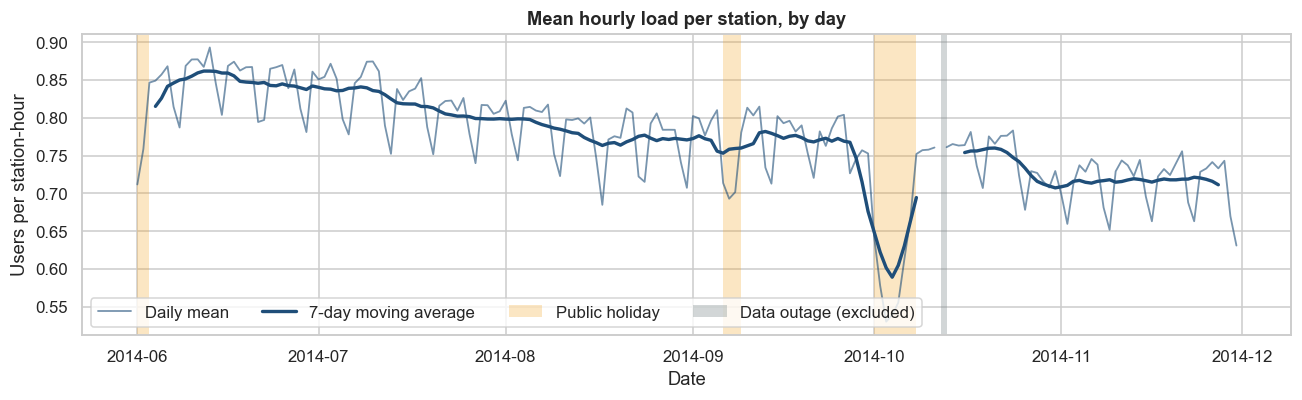

In [17]:
hourly_network = load.mean(axis=1)
daily_load = hourly_network.resample('D').mean()
daily_load = daily_load.where(hourly_network.resample('D').count() >= 20)   # gap on outage days

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(daily_load.index, daily_load.values, color=COLOR, lw=1.2, alpha=0.6, label='Daily mean')
ax.plot(daily_load.index, daily_load.rolling(7, center=True).mean(), color=COLOR, lw=2.2, label='7-day moving average')
for i, h in enumerate(HOLIDAYS):
    ax.axvspan(h, h + pd.Timedelta(days=1), color='#f39c12', alpha=0.25, lw=0,
               label='Public holiday' if i == 0 else None)
for i, d in enumerate(pd.DatetimeIndex(outage_hours).normalize().unique()):
    ax.axvspan(d, d + pd.Timedelta(days=1), color='#7f8c8d', alpha=0.35, lw=0,
               label='Data outage (excluded)' if i == 0 else None)
ax.set_title('Mean hourly load per station, by day')
ax.set_xlabel('Date')
ax.set_ylabel('Users per station-hour')
ax.legend(loc='lower left', ncol=4, frameon=True)
plt.tight_layout()
plt.show()

### 7.2 Distribution of Hourly Station Load

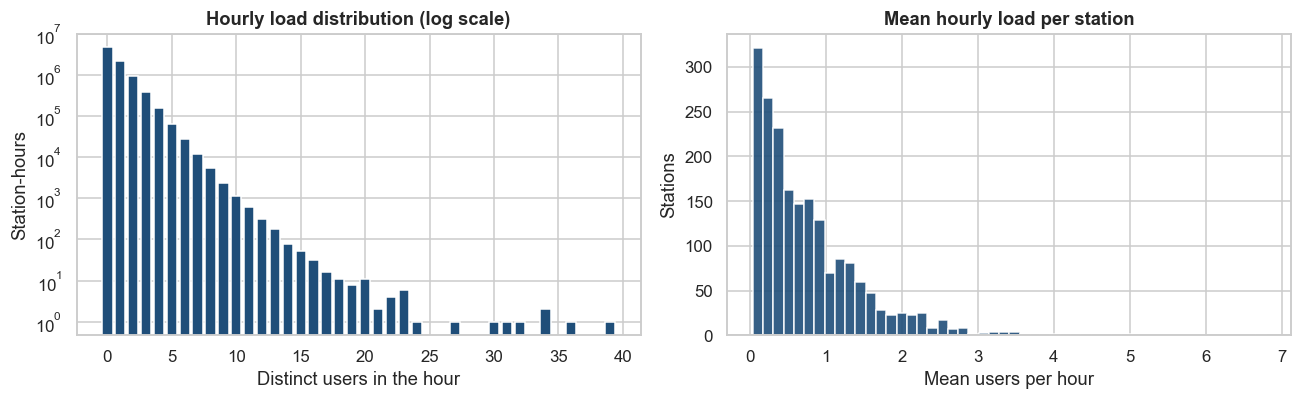

In [18]:
values = load.to_numpy().ravel()
counts = pd.Series(values).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(counts.index, counts.values, color=COLOR, width=0.8)
axes[0].set_yscale('log')
axes[0].set_title('Hourly load distribution (log scale)')
axes[0].set_xlabel('Distinct users in the hour')
axes[0].set_ylabel('Station-hours')

station_mean = load.mean()
axes[1].hist(station_mean, bins=50, color=COLOR, alpha=0.9)
axes[1].set_title('Mean hourly load per station')
axes[1].set_xlabel('Mean users per hour')
axes[1].set_ylabel('Stations')
plt.tight_layout()
plt.show()
del values

### 7.3 Daily and Weekly Pattern

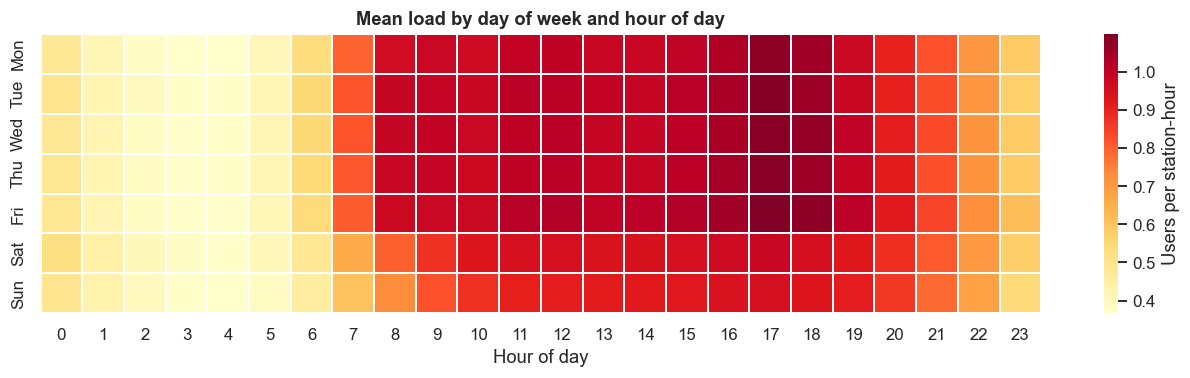

In [19]:
network = load.mean(axis=1)
profile = network.groupby([network.index.dayofweek, network.index.hour]).mean().unstack()
profile.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(12, 3.6))
sns.heatmap(profile, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Users per station-hour'})
ax.set_title('Mean load by day of week and hour of day')
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 7.4 Spatial Distribution of Load

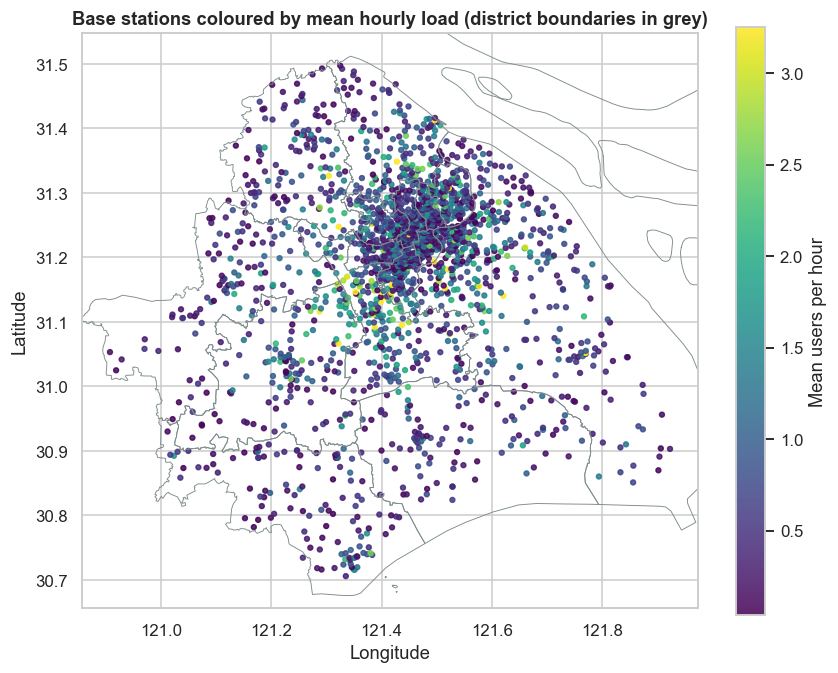

In [20]:
with open(DISTRICT_FILE, encoding='utf-8') as fh:
    district_geo = json.load(fh)

st = stations.loc[station_ids].assign(mean_load=load.mean().to_numpy())

fig, ax = plt.subplots(figsize=(8, 8))
for feature in district_geo['features']:
    geom = shape(feature['geometry'])
    for part in getattr(geom, 'geoms', [geom]):
        ax.plot(*part.exterior.xy, color='#7f8c8d', lw=0.6)
sc = ax.scatter(st['longitude'], st['latitude'], c=st['mean_load'], cmap='viridis',
                s=10, alpha=0.85, vmax=st['mean_load'].quantile(0.99))
fig.colorbar(sc, ax=ax, shrink=0.7, label='Mean users per hour')
ax.set_xlim(st['longitude'].min() - 0.05, st['longitude'].max() + 0.05)
ax.set_ylim(st['latitude'].min() - 0.05, st['latitude'].max() + 0.05)
ax.set_aspect(1 / np.cos(np.radians(31.2)))
ax.set_title('Base stations coloured by mean hourly load (district boundaries in grey)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

### 7.5 Load and Spikes by District

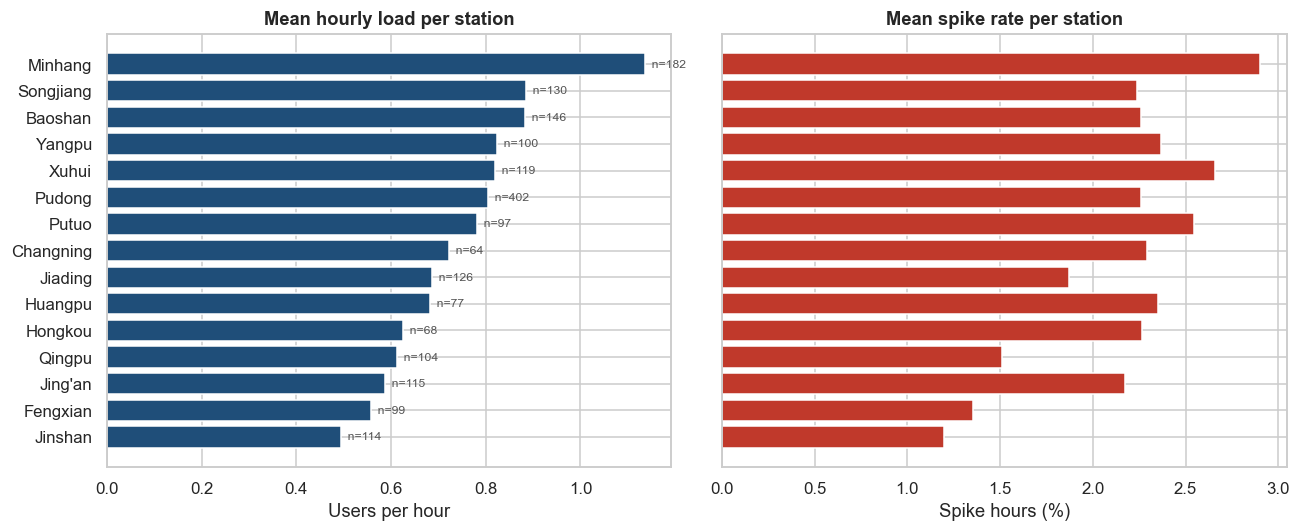

In [21]:
spike_rate_station = spike.mean() * 100
by_district = (st.assign(spike_rate=spike_rate_station.to_numpy())
                 .groupby('district')
                 .agg(stations=('mean_load', 'size'), mean_load=('mean_load', 'mean'),
                      spike_rate=('spike_rate', 'mean'))
                 .sort_values('mean_load'))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].barh(by_district.index, by_district['mean_load'], color=COLOR)
axes[0].set_title('Mean hourly load per station')
axes[0].set_xlabel('Users per hour')
for y, (v, n) in enumerate(zip(by_district['mean_load'], by_district['stations'])):
    axes[0].text(v, y, f'  n={n}', va='center', fontsize=8, color='#555555')
axes[1].barh(by_district.index, by_district['spike_rate'], color=ACCENT)
axes[1].set_title('Mean spike rate per station')
axes[1].set_xlabel('Spike hours (%)')
plt.tight_layout()
plt.show()

### 7.6 Example of Spike Detection

Two weeks of hourly load at the busiest station, with the spike threshold (mean + 2σ of the previous 7 days) and the detected spikes.

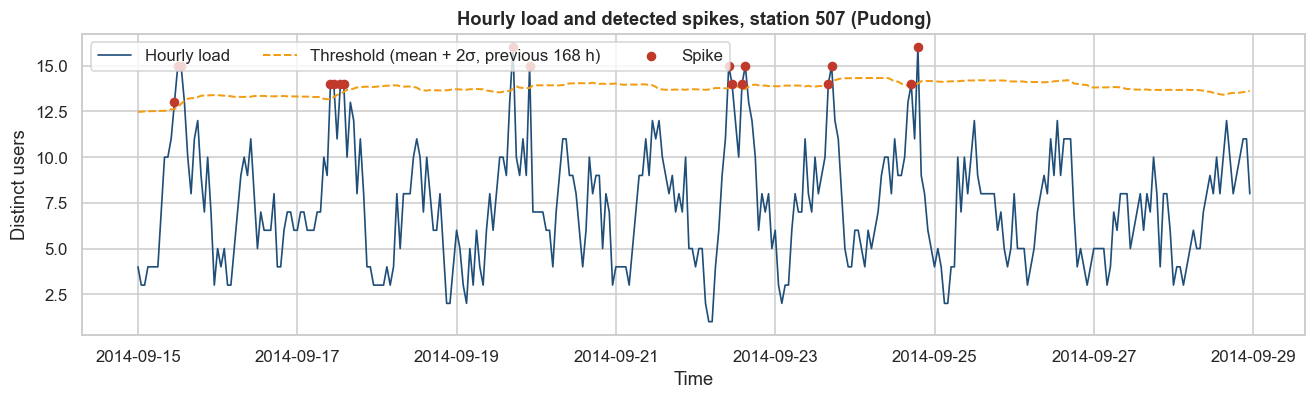

In [22]:
s_ex = load.sum().idxmax()
window = slice('2014-09-15', '2014-09-28')
series = load.loc[window, s_ex]
is_spike = (spike.loc[window, s_ex] == 1).to_numpy()

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(series.index, series.values, color=COLOR, lw=1.1, label='Hourly load')
ax.plot(series.index, threshold.loc[window, s_ex].values, color='#f39c12', lw=1.3, ls='--',
        label=f'Threshold (mean + {SPIKE_K:g}σ, previous {SPIKE_WINDOW} h)')
ax.scatter(series.index[is_spike], series.values[is_spike], color=ACCENT, s=28, zorder=3, label='Spike')
ax.set_title(f'Hourly load and detected spikes, station {s_ex} ({stations.loc[s_ex, "district"]})')
ax.set_xlabel('Time')
ax.set_ylabel('Distinct users')
ax.legend(loc='upper left', ncol=3, frameon=True)
plt.tight_layout()
plt.show()

### 7.7 When Do Spikes Occur?

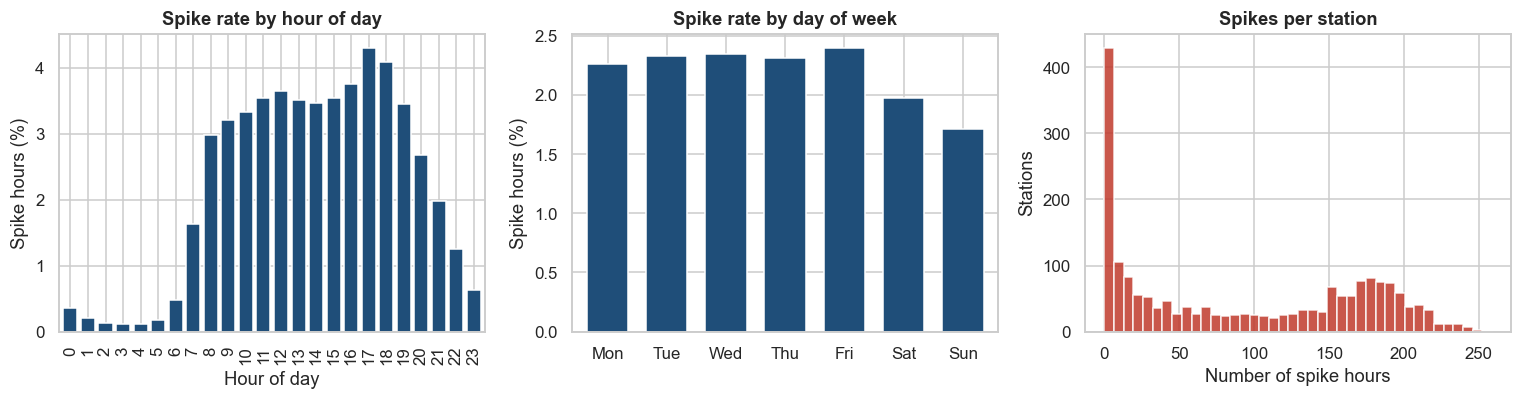

In [23]:
spike_long = spike.stack().rename('spike').reset_index()
spike_long.columns = ['hour', 'station_id', 'spike']

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
(spike_long.groupby(spike_long['hour'].dt.hour)['spike'].mean() * 100).plot.bar(ax=axes[0], color=COLOR, width=0.8)
axes[0].set_title('Spike rate by hour of day')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Spike hours (%)')

dow_rate = spike_long.groupby(spike_long['hour'].dt.dayofweek)['spike'].mean() * 100
dow_rate.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_rate.plot.bar(ax=axes[1], color=COLOR, width=0.7, rot=0)
axes[1].set_title('Spike rate by day of week')
axes[1].set_xlabel('')
axes[1].set_ylabel('Spike hours (%)')

axes[2].hist(spikes_per_station, bins=40, color=ACCENT, alpha=0.85)
axes[2].set_title('Spikes per station')
axes[2].set_xlabel('Number of spike hours')
axes[2].set_ylabel('Stations')
plt.tight_layout()
plt.show()
del spike_long

## 8. Feature Engineering

Each row is one station in one hour, labelled with whether a spike happens in the **next** hour. Features use only information available at the end of the current hour (calendar features describe the next hour, which is known in advance).

A broad set of **candidate features** is engineered here. Section 10 then selects a compact subset.

| Group | Features |
|---|---|
| Load history | Current load, lags, rolling mean / std / max, change, deviation from the spike baseline |
| Activity | Sessions started and session duration |
| Spike history | Recent spike counts and hours since the last spike |
| Spatial | Load and spikes at the nearest stations, city-wide load, location, station density |
| District | One-hot encoding of the station's district |
| Calendar | Hour, day of week, weekend and holiday flags, cyclical encodings |
| **Real-time state** | Users still connected at the end of the hour, compared with the spike threshold for the next hour |
| **Hourly profile** | The station's usual load, new arrivals and spikes at that hour of day over the last 7 days |

The last two groups follow how a spike forms: next hour's load = **users already connected** + **new arrivals**. The spike threshold for the next hour is already known from the past week, so the model is told how close the station is to it.

Features are computed on the *hours × stations* matrices and then flattened into a long table with one row per (station, hour).

In [24]:
n_h, n_s = load.shape

panel = pd.DataFrame({
    'timestamp':  np.repeat(hours.to_numpy(), n_s),
    'station_id': np.tile(station_ids, n_h).astype('int32'),
})
feature_info = {}    # feature name -> (group, description)


def add_wide(name, wide, group, desc):
    # hours x stations matrix -> panel column
    panel[name] = np.asarray(wide, dtype='float32').ravel()
    feature_info[name] = (group, desc)


def add_static(name, values, group, desc):
    # per-station constant, repeated for every hour
    panel[name] = np.tile(np.asarray(values, dtype='float32'), n_h)
    feature_info[name] = (group, desc)


def add_hourly(name, values, group, desc):
    # per-hour value, shared by all stations
    panel[name] = np.repeat(np.asarray(values, dtype='float32'), n_s)
    feature_info[name] = (group, desc)


def roll(frame, w):
    # Rolling window ending at t. Windows up to 24 h must be complete; the weekly window
    # tolerates up to MAX_MISSING_HOURS missing (outage) hours, like the spike baseline.
    return frame.rolling(w, min_periods=w if w <= 24 else w - MAX_MISSING_HOURS)


# =============================================================================
# Load history
# =============================================================================
G = 'Load history'
add_wide('load_t', load, G, 'Distinct users in hour t')
for lag in (1, 2, 3):
    add_wide(f'load_lag_{lag}', load.shift(lag), G, f'Load at t-{lag}')
add_wide('load_lag_23',  load.shift(23),  G, 'Load at t-23 (same hour yesterday as the target hour)')
add_wide('load_lag_167', load.shift(167), G, 'Load at t-167 (same hour last week as the target hour)')
for w in (3, 6, 24, 168):
    add_wide(f'load_roll_mean_{w}', roll(load, w).mean(), G, f'Mean load over the last {w} h')
for w in (24, 168):
    add_wide(f'load_roll_std_{w}', roll(load, w).std(), G, f'Std of load over the last {w} h')
    add_wide(f'load_roll_max_{w}', roll(load, w).max(), G, f'Max load over the last {w} h')
add_wide('load_diff_1', load - load.shift(1), G, 'Change in load from t-1 to t')
add_wide('load_ratio_24', load / (roll(load, 24).mean() + 1), G,
         'Load at t relative to its 24 h mean')
add_wide('load_zscore', (load - base_mean) / (base_std + 1), G,
         'Deviation of load at t from the spike baseline (previous 168 h)')
add_wide('load_expanding_mean', load.expanding().mean(), G, 'Long-run mean load of the station up to t')

# =============================================================================
# Activity: sessions started and duration
# =============================================================================
G = 'Activity'
add_wide('sessions_t', sessions, G, 'Sessions started in hour t')
add_wide('sessions_roll_mean_24', roll(sessions, 24).mean(), G,
         'Mean sessions started per hour over the last 24 h')
add_wide('dur_mean_t', (dur_sum / sessions.where(sessions > 0)).fillna(0).where(sessions.notna()), G,
         'Mean duration (min) of sessions started in hour t (0 if none)')
sess_24 = roll(sessions, 24).sum()
add_wide('dur_roll_mean_24',
         (roll(dur_sum, 24).sum() / sess_24.where(sess_24 > 0)).fillna(0).where(sess_24.notna()),
         G, 'Mean session duration (min) over the last 24 h')
del sess_24

# =============================================================================
# Spike history
# =============================================================================
G = 'Spike history'
spike_filled = spike.fillna(0)
spike_count_24 = spike_filled.rolling(24, min_periods=1).sum()
add_wide('spike_count_24',  spike_count_24, G, 'Spikes in the last 24 h (including t)')
add_wide('spike_count_168', spike_filled.rolling(168, min_periods=1).sum(), G, 'Spikes in the last 168 h (including t)')

idx = np.arange(n_h, dtype='float64')[:, None]
last_spike = pd.DataFrame(np.where(spike_filled.to_numpy() == 1, idx, np.nan)).ffill().to_numpy()
hours_since = np.minimum(idx - last_spike, HSS_CAP)
add_wide('hours_since_last_spike', np.where(np.isnan(hours_since), HSS_CAP, hours_since), G,
         f'Hours since the last spike (capped at {HSS_CAP})')
del idx, last_spike, hours_since

# =============================================================================
# Spatial
# =============================================================================
G = 'Spatial'
coords = stations.loc[station_ids, ['latitude', 'longitude']].to_numpy()
tree = BallTree(np.radians(coords), metric='haversine')
nbr_dist, nbr_idx = tree.query(np.radians(coords), k=N_NEIGHBOURS + 1)
nbr_dist, nbr_idx = nbr_dist[:, 1:] * 6371.0, nbr_idx[:, 1:]     # drop the station itself; radians -> km

load_np = load.to_numpy()
add_wide('nbr_load_t', load_np[:, nbr_idx].mean(axis=2), G,
         f'Mean load at t of the {N_NEIGHBOURS} nearest stations')
add_wide('nbr_load_roll_mean_24', roll(load, 24).mean().to_numpy()[:, nbr_idx].mean(axis=2), G,
         f'Mean 24 h load of the {N_NEIGHBOURS} nearest stations')
add_wide('nbr_spike_count_24', spike_count_24.to_numpy()[:, nbr_idx].sum(axis=2), G,
         f'Spikes in the last 24 h across the {N_NEIGHBOURS} nearest stations')
del load_np

city_load = load.sum(axis=1, min_count=1)      # missing (not 0) in outage hours
add_hourly('city_load_t', city_load, G, 'Total load at t across all selected stations')
add_hourly('city_load_ratio_24', city_load / (roll(city_load, 24).mean() + 1), G,
           'City-wide load at t relative to its 24 h mean')

lat_r, lon_r = np.radians(coords[:, 0]), np.radians(coords[:, 1])
c_lat, c_lon = np.radians(CITY_CENTRE[0]), np.radians(CITY_CENTRE[1])
dist_centre = 2 * 6371.0 * np.arcsin(np.sqrt(np.sin((lat_r - c_lat) / 2) ** 2
                                             + np.cos(lat_r) * np.cos(c_lat) * np.sin((lon_r - c_lon) / 2) ** 2))
add_static('latitude',  coords[:, 0], G, 'Station latitude')
add_static('longitude', coords[:, 1], G, 'Station longitude')
add_static('dist_to_centre_km', dist_centre, G, "Distance to the city centre (People's Square), km")
add_static('nbr_mean_dist_km', nbr_dist.mean(axis=1), G,
           f'Mean distance to the {N_NEIGHBOURS} nearest stations, km (station density)')

# =============================================================================
# District (one-hot)
# =============================================================================
G = 'District'
station_district = stations.loc[station_ids, 'district'].to_numpy()
for name in sorted(np.unique(station_district)):
    col = 'district_' + re.sub(r'\W', '', name).lower()
    add_static(col, station_district == name, G, f'Station is in {name}')

# =============================================================================
# Calendar (target hour t + 1)
# =============================================================================
G = 'Calendar'
target_time = hours + pd.Timedelta(hours=1)
hod, dow = target_time.hour.to_numpy(), target_time.dayofweek.to_numpy()
add_hourly('hour_of_day', hod, G, 'Hour of day of the target hour')
add_hourly('day_of_week', dow, G, 'Day of week of the target hour (0 = Monday)')
add_hourly('is_weekend', (dow >= 5) & ~target_time.normalize().isin(ADJUSTED_WORKDAYS), G,
           'Target hour is on a non-working Saturday or Sunday (make-up working days excluded)')
add_hourly('is_holiday', target_time.normalize().isin(HOLIDAYS), G, 'Target hour is on a public holiday')
add_hourly('hour_sin', np.sin(2 * np.pi * hod / 24), G, 'Cyclical encoding of hour of day (sine)')
add_hourly('hour_cos', np.cos(2 * np.pi * hod / 24), G, 'Cyclical encoding of hour of day (cosine)')
add_hourly('dow_sin',  np.sin(2 * np.pi * dow / 7),  G, 'Cyclical encoding of day of week (sine)')
add_hourly('dow_cos',  np.cos(2 * np.pi * dow / 7),  G, 'Cyclical encoding of day of week (cosine)')

# =============================================================================
# Real-time state: connected users vs. the spike threshold of hour t + 1
# =============================================================================
G = 'Real-time state'
next_window = load.rolling(SPIKE_WINDOW, min_periods=SPIKE_WINDOW - MAX_MISSING_HOURS)
thr_next = next_window.mean() + SPIKE_K * next_window.std()      # threshold for hour t+1 (window t-167..t)
eff_thr = np.maximum(thr_next, SPIKE_MIN_LOAD - 0.5)             # a spike also needs >= SPIKE_MIN_LOAD users
add_wide('carry_t', carry, G, 'Users still connected at the end of hour t')
add_wide('carry_lag_1', carry.shift(1), G, 'Users still connected at the end of hour t-1')
add_wide('sess_last15_t', sessions_late, G, 'Sessions started in the last 15 minutes of hour t')
add_wide('thr_next', thr_next, G, 'Spike threshold for hour t+1 (mean + 2 std of the previous 168 h)')
add_wide('gap_carry_thr', eff_thr - carry, G, 'Threshold for t+1 minus users still connected')
add_wide('gap_load_thr', eff_thr - load, G, 'Threshold for t+1 minus load at t')
add_wide('carry_over_thr', carry / eff_thr, G, 'Users still connected relative to the threshold for t+1')

# =============================================================================
# Hourly profile: what usually happens at the target hour of day
# =============================================================================
G = 'Hourly profile'
same_hour = [load.shift(23 + 24 * k) for k in range(7)]          # load at the target hour on each of the last 7 days
same_hour_mean = sum(same_hour) / 7
add_wide('same_hour_mean_7d', same_hour_mean, G, 'Mean load at the target hour of day over the last 7 days')
add_wide('same_hour_max_7d', np.maximum.reduce([s.to_numpy() for s in same_hour]), G,
         'Max load at the target hour of day over the last 7 days')
add_wide('gap_samehour_thr', eff_thr - same_hour_mean, G, 'Threshold for t+1 minus usual load at that hour')
add_wide('same_hour_spike_rate_7d', sum(spike_filled.shift(23 + 24 * k) for k in range(7)) / 7, G,
         'Spike rate at the target hour of day over the last 7 days')
add_wide('spike_lag_23', spike_filled.shift(23), G, 'Spike at the target hour of day yesterday')
add_wide('spike_lag_167', spike_filled.shift(167), G, 'Spike at the target hour one week earlier')
add_wide('spike_t', spike, G, 'Spike in hour t')

G = 'Real-time state'
add_wide('nbr_carry_t', carry.to_numpy()[:, nbr_idx].mean(axis=2), G,
         f'Mean users still connected at the {N_NEIGHBOURS} nearest stations')

G = 'Hourly profile'
arrivals = (load - carry.shift(1)).clip(lower=0)                  # users in hour h not carried over from h-1
same_arr = [arrivals.shift(23 + 24 * k) for k in range(7)]
arr_mean = sum(same_arr) / 7
expected_next = carry + arr_mean                                  # connected users + usual arrivals
add_wide('arr_t', arrivals, G, 'New arrivals in hour t (users not connected at the end of t-1)')
add_wide('arr_roll_mean_3', roll(arrivals, 3).mean(), G, 'Mean arrivals over the last 3 h')
add_wide('same_hour_arr_mean_7d', arr_mean, G, 'Mean arrivals at the target hour of day over the last 7 days')
add_wide('same_hour_arr_max_7d', np.maximum.reduce([s.to_numpy() for s in same_arr]), G,
         'Max arrivals at the target hour of day over the last 7 days')
add_wide('arr_lag_167', arrivals.shift(167), G, 'Arrivals at the target hour one week earlier')
add_wide('expected_next', expected_next, G, 'Expected load in t+1: users still connected + usual arrivals')
add_wide('gap_expected_thr', eff_thr - expected_next, G, 'Threshold for t+1 minus expected load')
add_wide('expected_over_thr', expected_next / eff_thr, G, 'Expected load in t+1 relative to the threshold')
add_wide('same_hour_carry_mean_7d', sum(carry.shift(23 + 24 * k) for k in range(7)) / 7, G,
         'Mean users still connected at the end of the target hour over the last 7 days')

G = 'Real-time state'
carry_over_thr = (carry / eff_thr).to_numpy()
add_wide('nbr_carry_over_thr', carry_over_thr[:, nbr_idx].mean(axis=2), G,
         'Neighbours: mean users still connected relative to their own threshold')
add_wide('nbr_carry_over_thr_max', carry_over_thr[:, nbr_idx].max(axis=2), G,
         'Neighbours: max users still connected relative to their own threshold')
del (next_window, thr_next, eff_thr, same_hour, same_hour_mean, arrivals, same_arr, arr_mean, expected_next,
     carry_over_thr)

# =============================================================================
# Target and final table
# =============================================================================
panel['target'] = np.asarray(target, dtype='float32').ravel()
n_before = len(panel)
panel = panel.dropna().reset_index(drop=True)
panel['target'] = panel['target'].astype('int8')

feature_cols = list(feature_info)

feature_catalogue = pd.DataFrame(
    [(name, grp, desc) for name, (grp, desc) in feature_info.items()],
    columns=['Feature', 'Group', 'Description'],
)
feature_catalogue.index = range(1, len(feature_catalogue) + 1)

print(f'Station-hours in panel           : {n_before:,}')
print(f'Removed (warm-up week, outage-affected hours, last hour): {n_before - len(panel):,}')
print(f'Station-hours in feature table   : {len(panel):,}')
print(f'Period (feature time t)          : {panel["timestamp"].min()} to {panel["timestamp"].max()}')
print(f'Candidate features               : {len(feature_cols)}')
print(f'Target positive rate             : {panel["target"].mean():.3%}\n')

display(feature_catalogue.groupby('Group', sort=False).size().rename('Features').to_frame()
          .style.set_caption('Table 20. Candidate features by group'))
display(feature_catalogue.style.set_caption('Table 21. Candidate feature catalogue'))

del (sessions, sessions_late, dur_sum, carry, baseline, base_mean, base_std, spike_filled, spike_count_24, target,
     nbr_dist, tree, city_load)

Station-hours in panel           : 8,533,656
Removed (warm-up week, outage-affected hours, last hour): 701,423
Station-hours in feature table   : 7,832,233
Period (feature time t)          : 2014-06-08 00:00:00 to 2014-11-30 22:00:00
Candidate features               : 83
Target positive rate             : 2.190%



,Features
Group,
Load history,18
Activity,4
Spike history,3
Spatial,9
District,15
Calendar,8
Real-time state,10
Hourly profile,16


,Feature,Group,Description
1,load_t,Load history,Distinct users in hour t
2,load_lag_1,Load history,Load at t-1
3,load_lag_2,Load history,Load at t-2
4,load_lag_3,Load history,Load at t-3
5,load_lag_23,Load history,Load at t-23 (same hour yesterday as the target hour)
6,load_lag_167,Load history,Load at t-167 (same hour last week as the target hour)
7,load_roll_mean_3,Load history,Mean load over the last 3 h
8,load_roll_mean_6,Load history,Mean load over the last 6 h
9,load_roll_mean_24,Load history,Mean load over the last 24 h
10,load_roll_mean_168,Load history,Mean load over the last 168 h


## 9. Train / Test Split (70 / 30)

The split is **chronological**: the first 70% of hours form the training set and the last 30% form the test set. All stations are included in both. A random split would place future hours in the training set. Lag and rolling features of neighbouring rows overlap in time, so this would leak test information into training.

The last 15% of the training period is held out as a **validation set**. It is used for feature selection, early stopping and choosing the decision threshold, so the **test set is used only once, for the final evaluation**.

| Set | Used for |
|---|---|
| Fit | Training the models |
| Validation | Feature selection, early stopping, decision threshold |
| Test | Final evaluation only |

In [25]:
unique_hours = np.sort(panel['timestamp'].unique())
split_time = unique_hours[int(len(unique_hours) * (1 - TEST_SIZE))]

train = panel[panel['timestamp'] <  split_time].reset_index(drop=True)
test  = panel[panel['timestamp'] >= split_time].reset_index(drop=True)
del panel

train_hours = np.sort(train['timestamp'].unique())
val_start = train_hours[int(len(train_hours) * (1 - VAL_SIZE))]
fit_mask = (train['timestamp'] < val_start).to_numpy()
fit, val = train[fit_mask].reset_index(drop=True), train[~fit_mask].reset_index(drop=True)
y_fit, y_val, y_te = fit['target'].to_numpy(), val['target'].to_numpy(), test['target'].to_numpy()

split_summary = pd.DataFrame([
    {'Set': name, 'Station-hours': len(part), 'Share (%)': len(part) / (len(train) + len(test)) * 100,
     'From': part['timestamp'].min(), 'To': part['timestamp'].max(),
     'Spikes': int(part['target'].sum()), 'Spike rate (%)': part['target'].mean() * 100}
    for name, part in (('Train: fit', fit), ('Train: validation', val), ('Test', test))
]).set_index('Set')

display(split_summary.style
        .format({'Station-hours': '{:,}', 'Share (%)': '{:.1f}', 'Spikes': '{:,}', 'Spike rate (%)': '{:.2f}'})
        .set_caption('Table 22. Chronological train / validation / test split'))

,Station-hours,Share (%),From,To,Spikes,Spike rate (%)
Set,,,,,,
Train: fit,"4,657,371",59.5,2014-06-08 00:00:00,2014-09-15 20:00:00,"104,874",2.25
Train: validation,"823,832",10.5,2014-09-15 21:00:00,2014-10-03 12:00:00,"16,462",2.00
Test,"2,351,030",30.0,2014-10-03 13:00:00,2014-11-30 22:00:00,"50,204",2.14


## 10. Feature Selection

The candidate set is reduced to a compact subset with an **embedded, validation-based procedure**:

1. **Ranking:** a LightGBM model with fixed settings is trained on all candidate features using the fit set, and features are ranked by their total split gain.
2. **Size search:** models are retrained using only the top 5, 10, 15, 20, 25, 30 and 40 features, and with all features, and scored on the validation set.
3. **Choice:** the **smallest set that scores within 1% of the best** is kept.

The test set is not used at any point in this procedure.

Ranking model trained in 3.1 min (375 trees)
Selected: top 15 of 83 features (validation PR-AUC 0.4429 vs best 0.4471)



,Validation PR-AUC,% of best
Features (k),,
5,0.4300,96.2
10,0.4398,98.4
15,0.4429,99.1
20,0.4446,99.4
25,0.4454,99.6
30,0.4467,99.9
40,0.4464,99.8
83,0.4471,100.0


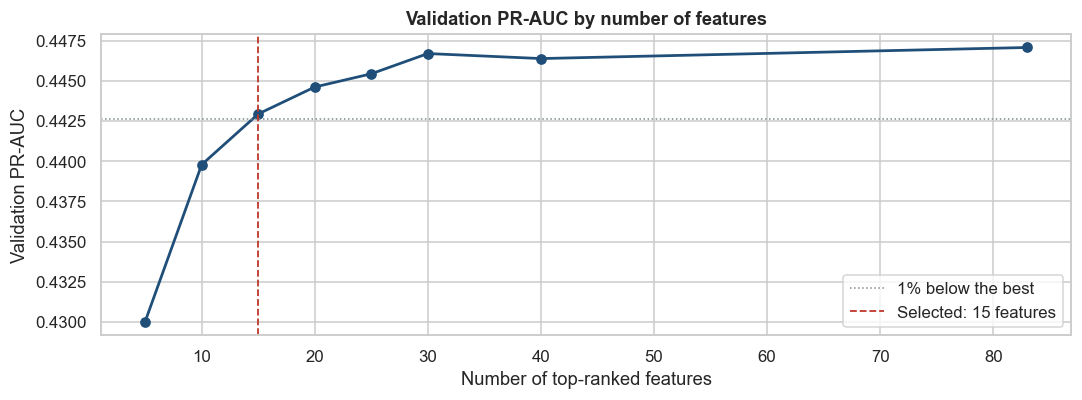

In [26]:
# =============================================================================
# 1) Rank all candidate features by LightGBM split gain (fit set)
# =============================================================================
base_params = {**LGB_BASE_PARAMS, 'scale_pos_weight': float((y_fit == 0).sum() / (y_fit == 1).sum())}


def train_lgb(params, feats, rounds=LGB_MAX_ROUNDS, stop=50):
    return lgb.train(params, lgb.Dataset(fit[feats], y_fit), rounds,
                     valid_sets=[lgb.Dataset(val[feats], y_val)],
                     callbacks=[lgb.early_stopping(stop, verbose=False)])


t0 = time.time()
ranker = train_lgb(base_params, feature_cols)
ranking = pd.Series(ranker.feature_importance('gain', iteration=ranker.best_iteration),
                    index=feature_cols).sort_values(ascending=False)
print(f'Ranking model trained in {(time.time() - t0) / 60:.1f} min ({ranker.best_iteration} trees)')

# =============================================================================
# 2) Validation PR-AUC for the top-k features
# =============================================================================
size_search = []
for k in SELECTION_K_GRID + [len(feature_cols)]:
    full = k == len(feature_cols)
    feats = feature_cols if full else list(ranking.index[:k])   # ranker was trained in feature_cols order
    m = ranker if full else train_lgb(base_params, feats)
    size_search.append({'Features (k)': k, 'Validation PR-AUC': average_precision_score(
        y_val, m.predict(val[feats], num_iteration=m.best_iteration))})
size_search = pd.DataFrame(size_search).set_index('Features (k)')
best_val = size_search['Validation PR-AUC'].max()
size_search['% of best'] = size_search['Validation PR-AUC'] / best_val * 100

# =============================================================================
# 3) Smallest k within the tolerance of the best
# =============================================================================
K = int(size_search.index[size_search['Validation PR-AUC'] >= best_val * (1 - SELECTION_TOLERANCE)].min())
selected_features = list(ranking.index[:K])
print(f'Selected: top {K} of {len(feature_cols)} features '
      f'(validation PR-AUC {size_search.loc[K, "Validation PR-AUC"]:.4f} vs best {best_val:.4f})\n')

display(size_search.style
        .format({'Validation PR-AUC': '{:.4f}', '% of best': '{:.1f}'})
        .apply(lambda r: ['background-color: #d5f5e3' if r.name == K else '' for _ in r], axis=1)
        .set_caption('Table 23. Validation PR-AUC by number of features (selected size highlighted)'))

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(size_search.index, size_search['Validation PR-AUC'], color=COLOR, marker='o', lw=1.8)
ax.axhline(best_val * (1 - SELECTION_TOLERANCE), color='#7f8c8d', ls=':', lw=1,
           label=f'{SELECTION_TOLERANCE:.0%} below the best')
ax.axvline(K, color=ACCENT, ls='--', lw=1.2, label=f'Selected: {K} features')
ax.set_title('Validation PR-AUC by number of features')
ax.set_xlabel('Number of top-ranked features')
ax.set_ylabel('Validation PR-AUC')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 10.1 Selected Features

In [27]:
palette = dict(zip(feature_catalogue['Group'].unique(), sns.color_palette('tab10')))

selected_table = pd.DataFrame({
    'Group': [feature_info[f][0] for f in selected_features],
    'Description': [feature_info[f][1] for f in selected_features],
    'Gain (% of total)': ranking[selected_features] / ranking.sum() * 100,
}, index=pd.Index(selected_features, name='Feature'))
selected_table.insert(0, 'Rank', range(1, K + 1))

display(selected_table.style
        .format({'Gain (% of total)': '{:.2f}'})
        .set_caption(f'Table 24. The {K} selected features'))

print(selected_table['Group'].value_counts().rename('Selected features').to_string())

,Rank,Group,Description,Gain (% of total)
Feature,,,,
expected_over_thr,1,Hourly profile,Expected load in t+1 relative to the threshold,72.93
gap_load_thr,2,Real-time state,Threshold for t+1 minus load at t,10.55
hour_of_day,3,Calendar,Hour of day of the target hour,3.12
load_roll_std_168,4,Load history,Std of load over the last 168 h,1.59
hours_since_last_spike,5,Spike history,Hours since the last spike (capped at 720),1.25
carry_over_thr,6,Real-time state,Users still connected relative to the threshold for t+1,0.73
gap_carry_thr,7,Real-time state,Threshold for t+1 minus users still connected,0.48
load_expanding_mean,8,Load history,Long-run mean load of the station up to t,0.43
load_zscore,9,Load history,Deviation of load at t from the spike baseline (previous 168 h),0.41


Group
Spatial            4
Load history       3
Real-time state    3
Calendar           2
Hourly profile     1
Spike history      1
Activity           1


## 11. Feature Scaling

The selected features are standardised to zero mean and unit variance (`StandardScaler`, z-score). The scaler is fitted on the **fit set only** and applied unchanged to the validation and test sets.

Scaling is required by **logistic regression**, which is sensitive to feature scale. **LightGBM** is trained on the unscaled features: tree splits are unaffected by scale, and unscaled values keep feature importances in original units.

In [28]:
scaler = StandardScaler().fit(fit[selected_features])
X_fit_s = scaler.transform(fit[selected_features]).astype('float32')
X_val_s = scaler.transform(val[selected_features]).astype('float32')
X_te_s  = scaler.transform(test[selected_features]).astype('float32')

scaling_check = pd.DataFrame({
    'Fit mean (before)': fit[selected_features].mean(),
    'Fit std (before)':  fit[selected_features].std(),
    'Fit mean (after)':  X_fit_s.mean(axis=0),
    'Fit std (after)':   X_fit_s.std(axis=0),
    'Test mean (after)': X_te_s.mean(axis=0),
    'Test std (after)':  X_te_s.std(axis=0),
}, index=pd.Index(selected_features, name='Feature'))
display(scaling_check.style.format('{:.3f}')
        .set_caption('Table 25. Feature scaling check (fit-set statistics are 0 / 1 after scaling)'))

,Fit mean (before),Fit std (before),Fit mean (after),Fit std (after),Test mean (after),Test std (after)
Feature,,,,,,
expected_over_thr,0.233,0.260,-0.000,1.000,-0.072,0.982
gap_load_thr,2.235,1.003,0.000,1.000,-0.012,0.940
hour_of_day,11.496,6.915,-0.000,1.000,0.009,1.002
load_roll_std_168,0.778,0.408,-0.000,1.000,-0.102,0.961
hours_since_last_spike,246.460,290.694,-0.000,1.000,0.041,1.001
carry_over_thr,0.114,0.203,-0.000,1.000,-0.038,0.983
gap_carry_thr,2.644,0.972,-0.000,1.000,-0.064,0.904
load_expanding_mean,0.827,0.764,-0.000,1.000,-0.059,0.930
load_zscore,0.001,0.439,-0.000,1.000,0.007,0.976


## 12. Models

Three approaches are compared, all trained on the fit set with the same selected features, with the decision threshold chosen on the validation set:

| Model | Role | Description |
|---|---|---|
| **Persistence** | Naive baseline | Predicts a spike next hour if there is a spike now. No training |
| **Logistic regression** | Linear baseline | Linear model on the scaled features, with balanced class weights |
| **LightGBM** | Proposed model | Gradient-boosted decision trees (Ke et al., 2017), hyperparameters tuned with Optuna |

**Decision threshold:** each model outputs a spike probability. The cut-off that turns it into a yes / no prediction is the one that maximises F1 on the validation set.

### 12.1 LightGBM Hyperparameter Tuning

Hyperparameters were tuned with **Optuna** (Tree-structured Parzen Estimator, 25 trials). Each trial was trained on a 35% random sample of the fit set with learning rate 0.1 and early stopping, and scored by **validation PR-AUC**. The final model uses the best configuration with a lower learning rate (0.03) and the full fit set.

The tuning run takes about 12 minutes, so it is switched off by default (`RUN_TUNING = False`) and the tuned values are set in the configuration cell. Set `RUN_TUNING = True` to repeat it.

In [29]:
search_space = pd.DataFrame([
    ('num_leaves',        '31 – 511 (log)',   LGB_PARAMS['num_leaves']),
    ('min_child_samples', '20 – 2000 (log)',  LGB_PARAMS['min_child_samples']),
    ('feature_fraction',  '0.4 – 1.0',        LGB_PARAMS['feature_fraction']),
    ('bagging_fraction',  '0.5 – 1.0',        LGB_PARAMS['bagging_fraction']),
    ('lambda_l1',         '0.001 – 10 (log)', LGB_PARAMS['lambda_l1']),
    ('lambda_l2',         '0.001 – 50 (log)', LGB_PARAMS['lambda_l2']),
    ('min_gain_to_split', '0 – 1',            LGB_PARAMS['min_gain_to_split']),
    ('scale_pos_weight',  '1 – 50 (log)',     LGB_PARAMS['scale_pos_weight']),
], columns=['Hyperparameter', 'Search range', 'Selected value']).set_index('Hyperparameter')
display(search_space.style.format({'Selected value': '{:g}'})
        .set_caption('Table 26. LightGBM hyperparameter search space and selected values'))

if RUN_TUNING:
    import optuna
    rng = np.random.default_rng(SEED)
    sample = rng.random(len(fit)) < 0.35
    d_tr = lgb.Dataset(fit.loc[sample, selected_features], y_fit[sample], free_raw_data=False)
    d_va = lgb.Dataset(val[selected_features], y_val, reference=d_tr, free_raw_data=False)

    def objective(trial):
        p = {'objective': 'binary', 'metric': 'average_precision', 'verbosity': -1, 'seed': SEED,
             'learning_rate': 0.1, 'bagging_freq': 1,
             'num_leaves': trial.suggest_int('num_leaves', 31, 511, log=True),
             'min_child_samples': trial.suggest_int('min_child_samples', 20, 2000, log=True),
             'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
             'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
             'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10, log=True),
             'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 50, log=True),
             'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0),
             'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 50.0, log=True)}
        m = lgb.train(p, d_tr, 2000, valid_sets=[d_va], callbacks=[lgb.early_stopping(50, verbose=False)])
        return m.best_score['valid_0']['average_precision']

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=TUNING_TRIALS)
    LGB_PARAMS.update(study.best_params)
    print(f'Best validation PR-AUC (sampled): {study.best_value:.4f}')
    display(pd.Series(study.best_params, name='Tuned value').to_frame())

,Search range,Selected value
Hyperparameter,,
num_leaves,31 – 511 (log),35
min_child_samples,20 – 2000 (log),527
feature_fraction,0.4 – 1.0,0.828
bagging_fraction,0.5 – 1.0,0.803
lambda_l1,0.001 – 10 (log),1.649
lambda_l2,0.001 – 50 (log),5.388
min_gain_to_split,0 – 1,0.361
scale_pos_weight,1 – 50 (log),1.159


### 12.2 Model Training

,Training time (min),Validation PR-AUC,Decision threshold
Model,,,
Persistence,0.0,0.1296,0.5000
Logistic regression,0.2,0.3778,0.9301
LightGBM,4.5,0.4469,0.2575


LightGBM: 1275 trees (early stopping)


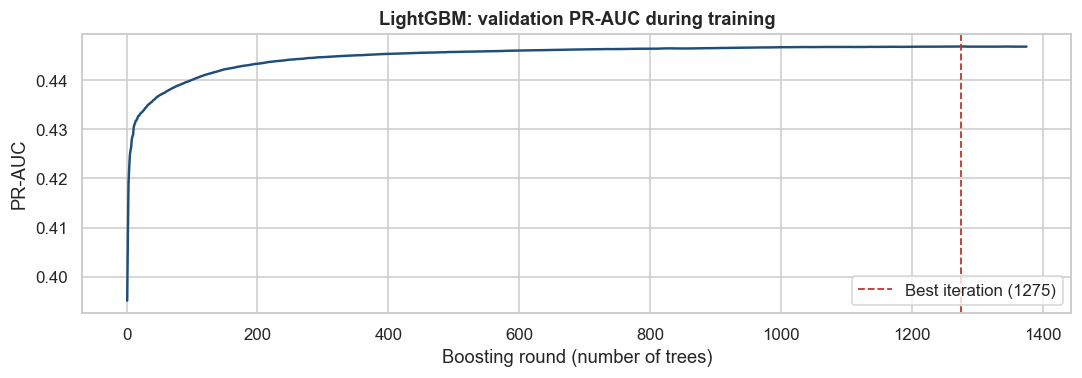

In [30]:
def best_threshold(y_true, scores):
    # Probability cut-off that maximises F1 on the given (validation) data
    prec, rec, thr = precision_recall_curve(y_true, scores)
    f1 = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
    return float(thr[np.argmax(f1)])


# =============================================================================
# LightGBM (unscaled features)
# =============================================================================
t0 = time.time()
history = {}
model = lgb.train(LGB_PARAMS, lgb.Dataset(fit[selected_features], y_fit), LGB_MAX_ROUNDS,
                  valid_sets=[lgb.Dataset(val[selected_features], y_val)], valid_names=['validation'],
                  callbacks=[lgb.early_stopping(LGB_EARLY_STOPPING, verbose=False), lgb.record_evaluation(history)])
best_iter = model.best_iteration
lgb_time = time.time() - t0
p_val_lgb = model.predict(val[selected_features], num_iteration=best_iter)
p_te_lgb  = model.predict(test[selected_features], num_iteration=best_iter)

# =============================================================================
# Logistic regression (scaled features)
# =============================================================================
t0 = time.time()
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED).fit(X_fit_s, y_fit)
lr_time = time.time() - t0
p_val_lr = logreg.predict_proba(X_val_s)[:, 1]
p_te_lr  = logreg.predict_proba(X_te_s)[:, 1]

# =============================================================================
# Persistence (spike now -> spike next hour)
# =============================================================================
p_val_per = (val['hours_since_last_spike'] == 0).astype(float).to_numpy()
p_te_per  = (test['hours_since_last_spike'] == 0).astype(float).to_numpy()

thresholds = {'Persistence': 0.5,
              'Logistic regression': best_threshold(y_val, p_val_lr),
              'LightGBM': best_threshold(y_val, p_val_lgb)}
threshold = thresholds['LightGBM']

training_summary = pd.DataFrame({
    'Training time (min)': [0.0, lr_time / 60, lgb_time / 60],
    'Validation PR-AUC': [average_precision_score(y_val, p_val_per), average_precision_score(y_val, p_val_lr),
                          average_precision_score(y_val, p_val_lgb)],
    'Decision threshold': list(thresholds.values()),
}, index=pd.Index(list(thresholds), name='Model'))
display(training_summary.style.format({'Training time (min)': '{:.1f}', 'Validation PR-AUC': '{:.4f}',
                                       'Decision threshold': '{:.4f}'})
        .set_caption('Table 27. Model training summary'))
print(f'LightGBM: {best_iter} trees (early stopping)')

val_curve = history['validation']['average_precision']
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(range(1, len(val_curve) + 1), val_curve, color=COLOR, lw=1.6)
ax.axvline(best_iter, color=ACCENT, ls='--', lw=1.2, label=f'Best iteration ({best_iter})')
ax.set_title('LightGBM: validation PR-AUC during training')
ax.set_xlabel('Boosting round (number of trees)')
ax.set_ylabel('PR-AUC')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 13. Model Evaluation

All three models are evaluated **once** on the held-out test set, with thresholds fixed on the validation set.

| Metric | Meaning |
|---|---|
| **PR-AUC** (primary) | Area under the precision–recall curve. Threshold-independent and focused on the rare positive class; a random model scores the positive rate (about 0.02) |
| ROC-AUC | Probability that a random spike hour is ranked above a random normal hour |
| Precision | Share of predicted spikes that are real |
| Recall | Share of real spikes that are detected |
| F1 | Harmonic mean of precision and recall |

Accuracy is not used as a metric. At a 2.2% positive rate, predicting "no spike" everywhere would already score about 97.8%. It is shown in the table only for reference.

### 13.1 Test Set Performance

In [31]:
X_te = test[selected_features]
p_test = p_te_lgb
y_pred = (p_test >= threshold).astype(int)
y_persist = p_te_per.astype(int)

test_scores = {'Persistence': p_te_per, 'Logistic regression': p_te_lr, 'LightGBM': p_te_lgb}


def evaluate(y_true, scores, thr):
    y_hat = (scores >= thr).astype(int)
    return {
        'PR-AUC': average_precision_score(y_true, scores),
        'ROC-AUC': roc_auc_score(y_true, scores),
        'Precision': precision_score(y_true, y_hat, zero_division=0),
        'Recall': recall_score(y_true, y_hat),
        'F1': f1_score(y_true, y_hat),
        'Accuracy': (y_hat == y_true).mean(),
        'Predicted spikes': int(y_hat.sum()),
    }


results = pd.DataFrame({name: evaluate(y_te, s, thresholds[name]) for name, s in test_scores.items()}).T
results.loc['Always "no spike"'] = {'PR-AUC': y_te.mean(), 'ROC-AUC': 0.5, 'Precision': np.nan, 'Recall': 0.0,
                                     'F1': 0.0, 'Accuracy': 1 - y_te.mean(), 'Predicted spikes': 0}
results = results.loc[['Always "no spike"', 'Persistence', 'Logistic regression', 'LightGBM']].rename_axis('Model')

print(f'Test station-hours : {len(y_te):,}')
print(f'Actual spikes      : {int(y_te.sum()):,} ({y_te.mean():.2%})')
print(f'Features used      : {len(selected_features)}\n')
display(results.style
        .format({'PR-AUC': '{:.4f}', 'ROC-AUC': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
                 'F1': '{:.4f}', 'Accuracy': '{:.4f}', 'Predicted spikes': '{:,.0f}'}, na_rep='–')
        .highlight_max(subset=['PR-AUC', 'ROC-AUC', 'F1'], color='#d5f5e3')
        .set_caption('Table 28. Test set performance'))

gain_lr = (results.loc['LightGBM', 'PR-AUC'] / results.loc['Logistic regression', 'PR-AUC'] - 1) * 100
gain_per = (results.loc['LightGBM', 'PR-AUC'] / results.loc['Persistence', 'PR-AUC'] - 1) * 100
print(f'LightGBM PR-AUC vs logistic regression : {gain_lr:+.1f}%')
print(f'LightGBM PR-AUC vs persistence         : {gain_per:+.1f}%')

Test station-hours : 2,351,030
Actual spikes      : 50,204 (2.14%)
Features used      : 15



,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy,Predicted spikes
Model,,,,,,,
"Always ""no spike""",0.0214,0.5000,–,0.0000,0.0000,0.9786,0
Persistence,0.1356,0.6674,0.3488,0.3490,0.3489,0.9722,"50,245"
Logistic regression,0.4022,0.9403,0.4071,0.4251,0.4159,0.9745,"52,424"
LightGBM,0.4667,0.9488,0.4603,0.4335,0.4465,0.9771,"47,278"


LightGBM PR-AUC vs logistic regression : +16.0%
LightGBM PR-AUC vs persistence         : +244.1%


### 13.2 Precision–Recall and ROC Curves

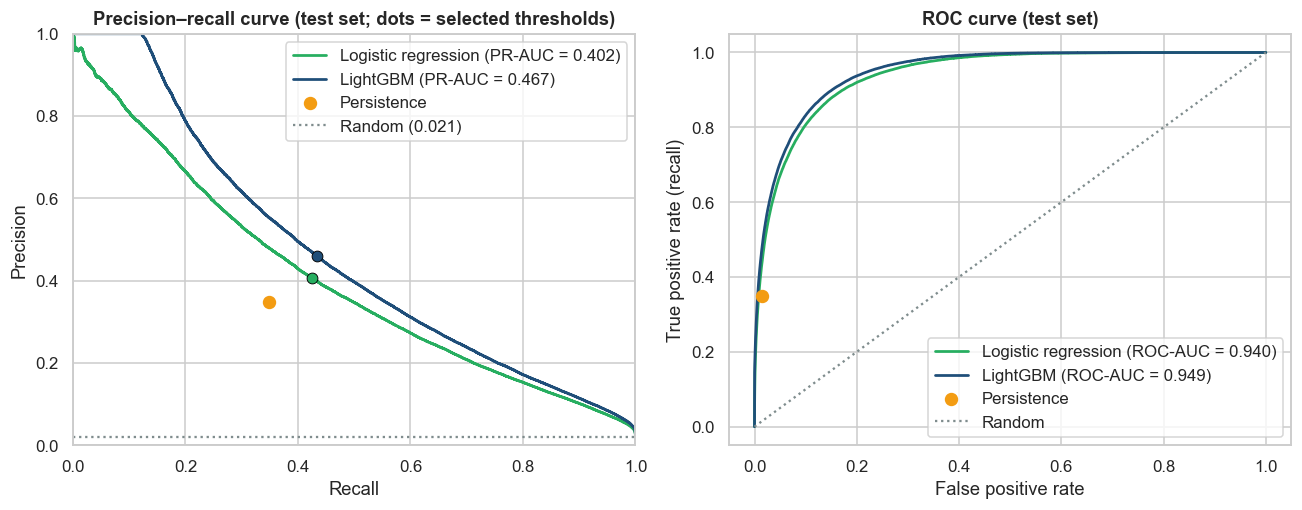

In [32]:
MODEL_COLORS = {'Logistic regression': '#27ae60', 'LightGBM': COLOR}
persist_prec, persist_rec = precision_score(y_te, y_persist), recall_score(y_te, y_persist)
persist_fpr = ((y_persist == 1) & (y_te == 0)).sum() / (y_te == 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for name, color in MODEL_COLORS.items():
    prec_c, rec_c, _ = precision_recall_curve(y_te, test_scores[name])
    fpr_c, tpr_c, _ = roc_curve(y_te, test_scores[name])
    axes[0].plot(rec_c, prec_c, color=color, lw=1.8, label=f'{name} (PR-AUC = {results.loc[name, "PR-AUC"]:.3f})')
    axes[1].plot(fpr_c, tpr_c, color=color, lw=1.8, label=f'{name} (ROC-AUC = {results.loc[name, "ROC-AUC"]:.3f})')
    axes[0].scatter(results.loc[name, 'Recall'], results.loc[name, 'Precision'], color=color, s=50, zorder=3,
                    edgecolor='black', linewidth=0.6)
axes[0].scatter(persist_rec, persist_prec, color='#f39c12', s=60, zorder=3, label='Persistence')
axes[0].axhline(y_te.mean(), color='#7f8c8d', ls=':', label=f'Random ({y_te.mean():.3f})')
axes[0].set_title('Precision–recall curve (test set; dots = selected thresholds)')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(loc='upper right')

axes[1].scatter(persist_fpr, persist_rec, color='#f39c12', s=60, zorder=3, label='Persistence')
axes[1].plot([0, 1], [0, 1], color='#7f8c8d', ls=':', label='Random')
axes[1].set_title('ROC curve (test set)')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate (recall)')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

### 13.3 Confusion Matrix

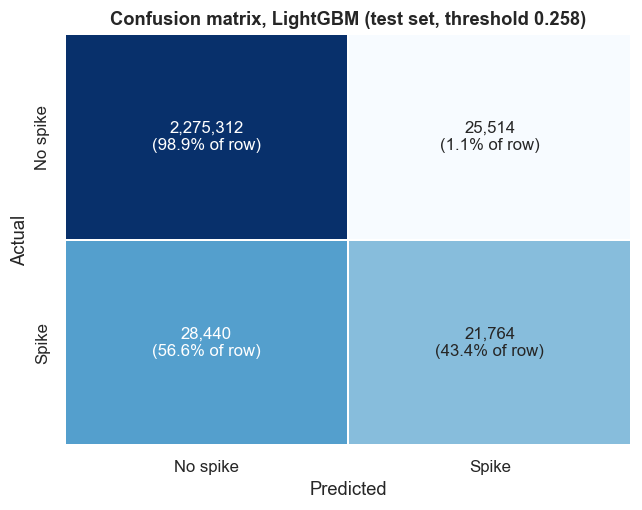

True positives  (spikes detected)    : 21,764
False negatives (spikes missed)      : 28,440
False positives (false alarms)       : 25,514
True negatives  (normal hours)       : 2,275,312


In [33]:
cm = confusion_matrix(y_te, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
labels = np.array([[f'{n:,}\n({p:.1f}% of row)' for n, p in zip(r_n, r_p)] for r_n, r_p in zip(cm, cm_pct)])

fig, ax = plt.subplots(figsize=(6, 4.8))
sns.heatmap(cm_pct, annot=labels, fmt='', cmap='Blues', cbar=False, linewidths=1, ax=ax,
            xticklabels=['No spike', 'Spike'], yticklabels=['No spike', 'Spike'], annot_kws={'size': 11})
ax.set_title(f'Confusion matrix, LightGBM (test set, threshold {threshold:.3f})')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True positives  (spikes detected)    : {tp:,}')
print(f'False negatives (spikes missed)      : {fn:,}')
print(f'False positives (false alarms)       : {fp:,}')
print(f'True negatives  (normal hours)       : {tn:,}')

### 13.4 Feature Importance

Two complementary views:

- **Gain:** the total improvement in the training loss from splits on each feature.
- **Mean |SHAP|:** the average absolute contribution of each feature to individual test predictions (log-odds scale), computed natively by LightGBM on a random sample of 50,000 test rows. SHAP values are additive and consistent, which makes them the standard for model explanation.

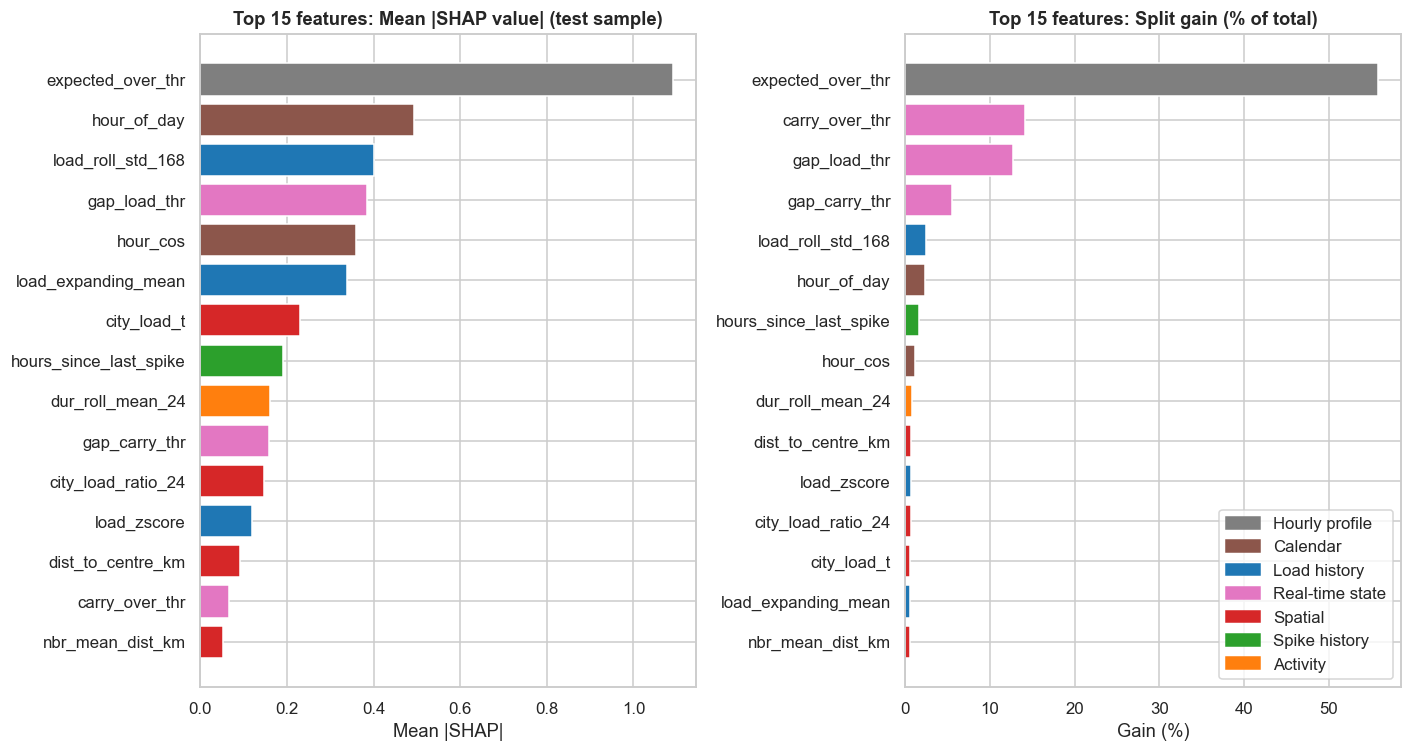

,Group,Gain (%),Mean |SHAP|
Feature,,,
expected_over_thr,Hourly profile,55.80,1.0905
hour_of_day,Calendar,2.26,0.4931
load_roll_std_168,Load history,2.40,0.4004
gap_load_thr,Real-time state,12.76,0.3857
hour_cos,Calendar,1.14,0.3599
load_expanding_mean,Load history,0.57,0.3391
city_load_t,Spatial,0.58,0.2308
hours_since_last_spike,Spike history,1.62,0.1900
dur_roll_mean_24,Activity,0.75,0.1615


In [34]:
gain = pd.Series(model.feature_importance('gain', iteration=best_iter), index=selected_features)
gain = gain / gain.sum() * 100

shap_rows = X_te.sample(n=min(SHAP_SAMPLE_SIZE, len(X_te)), random_state=SEED)
contrib = model.predict(shap_rows, num_iteration=best_iter, pred_contrib=True)[:, :-1]   # last column = bias
mean_shap = pd.Series(np.abs(contrib).mean(axis=0), index=selected_features)

importance = pd.DataFrame({
    'Group': [feature_info[f][0] for f in selected_features],
    'Gain (%)': gain,
    'Mean |SHAP|': mean_shap,
}).rename_axis('Feature').sort_values('Mean |SHAP|', ascending=False)

TOP = min(20, len(selected_features))
fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=False)
for ax, col, title in ((axes[0], 'Mean |SHAP|', 'Mean |SHAP value| (test sample)'),
                       (axes[1], 'Gain (%)', 'Split gain (% of total)')):
    top = importance.sort_values(col, ascending=False).head(TOP).iloc[::-1]
    ax.barh(top.index, top[col], color=[palette[g] for g in top['Group']])
    ax.set_title(f'Top {TOP} features: {title}')
    ax.set_xlabel(col)
handles = [plt.Rectangle((0, 0), 1, 1, color=palette[g]) for g in importance['Group'].unique()]
axes[1].legend(handles, importance['Group'].unique(), loc='lower right')
plt.tight_layout()
plt.show()

display(importance.style
        .format({'Gain (%)': '{:.2f}', 'Mean |SHAP|': '{:.4f}'})
        .bar(subset=['Mean |SHAP|'], color='#aed6f1')
        .set_caption('Table 29. LightGBM feature importance (sorted by mean |SHAP|)'))
del contrib, shap_rows

### 13.5 Performance on Holidays and Special Events

Overall metrics can hide weaknesses on unusual days. Every test day is assigned to one category, and the model is evaluated separately on each:

| Category | Definition |
|---|---|
| Public holiday | Official holiday (State Council 2014 schedule) |
| Adjusted working day | Weekend day that was an official working day |
| Special event | Major city event: sports, exhibition or commercial festival (table below) |
| Weekend | Other Saturdays and Sundays |
| Normal weekday | All other days |

If a day matches more than one category, the first one in this order applies. Days are taken from the **target hour** (the hour being predicted). The persistence baseline is shown alongside, so differences between categories can be separated from differences in how hard each category is.

**Caveat:** the test period contains only a few holiday and event days, so these results are descriptive and should not be treated as statistically conclusive.

Event sources: 2014 State Council holiday schedule; ATP (Shanghai Rolex Masters, 5–12 Oct); FIA WEC (6 Hours of Shanghai, 31 Oct – 2 Nov); Shanghai International Marathon (2 Nov); CIIF (4–8 Nov).

First day,Last day,Event,Type,Location
2014-10-01,2014-10-07,National Day Golden Week,Public holiday,Nationwide
2014-10-05,2014-10-12,Shanghai Rolex Masters (ATP tennis),Special event,"Qizhong Arena, Minhang"
2014-10-11,2014-10-11,Make-up working day (Saturday),Adjusted working day,Nationwide
2014-10-31,2014-11-02,FIA WEC 6 Hours of Shanghai,Special event,"Shanghai International Circuit, Jiading"
2014-11-02,2014-11-02,Shanghai International Marathon,Special event,City centre
2014-11-04,2014-11-08,China International Industry Fair,Special event,"SNIEC, Pudong"
2014-11-11,2014-11-11,Singles' Day (Double 11) shopping festival,Special event,Online / nationwide


,Days,Station-hours,Spikes,Spike rate (%),PR-AUC,Precision,Recall,F1,F1 (persistence)
Category,,,,,,,,,
Public holiday,5,"205,958","3,238",1.57,0.4367,0.4616,0.3931,0.4246,0.3420
Adjusted working day,1,"46,632","1,257",2.70,0.4848,0.4825,0.4503,0.4658,0.3455
Special event,12,"559,584","13,884",2.48,0.4894,0.4821,0.4442,0.4624,0.3650
Weekend,9,"419,688","7,224",1.72,0.4509,0.4552,0.4197,0.4367,0.3485
Normal weekday,24,"1,119,168","24,601",2.20,0.4620,0.4489,0.4360,0.4423,0.3410
All test days,51,"2,351,030","50,204",2.14,0.4667,0.4603,0.4335,0.4465,0.3489


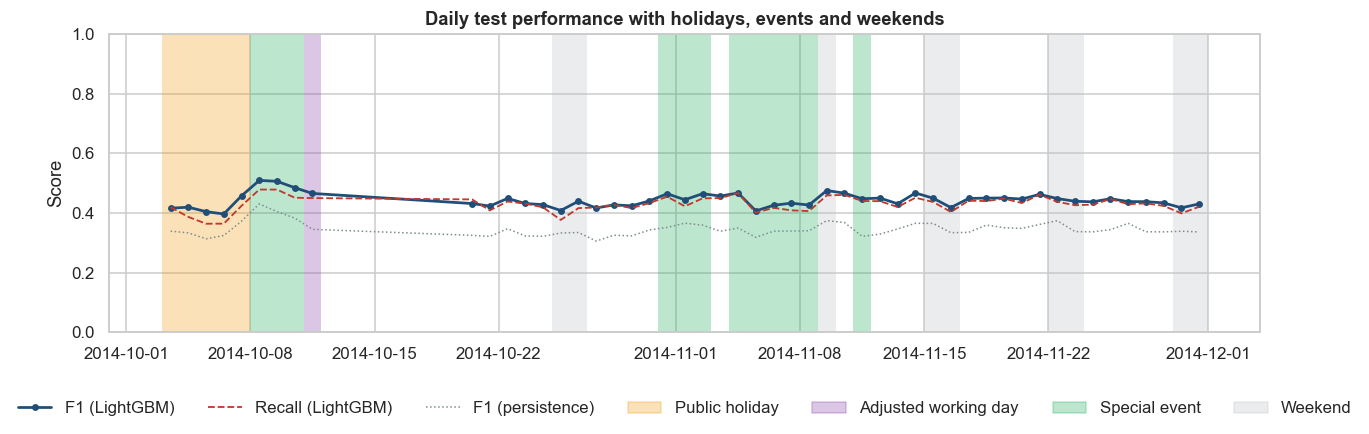

,Category,Events,Spikes,Spike rate (%),PR-AUC,Precision,Recall,F1,F1 (persistence)
date,,,,,,,,,
2014-10-03 (Fri),Public holiday,National Day Golden Week,255,1.31,0.4459,0.4131,0.4196,0.4163,0.3394
2014-10-04 (Sat),Public holiday,National Day Golden Week,527,1.13,0.4154,0.4584,0.3871,0.4198,0.3337
2014-10-05 (Sun),Public holiday,National Day Golden Week; Shanghai Rolex Masters (ATP tennis),560,1.20,0.4166,0.4554,0.3643,0.4048,0.3137
2014-10-06 (Mon),Public holiday,National Day Golden Week; Shanghai Rolex Masters (ATP tennis),779,1.67,0.3915,0.4356,0.3646,0.3969,0.3247
2014-10-07 (Tue),Public holiday,National Day Golden Week; Shanghai Rolex Masters (ATP tennis),"1,117",2.40,0.4876,0.4969,0.4244,0.4577,0.3728
2014-10-08 (Wed),Special event,Shanghai Rolex Masters (ATP tennis),"1,708",3.66,0.5608,0.5442,0.4789,0.5095,0.4306
2014-10-09 (Thu),Special event,Shanghai Rolex Masters (ATP tennis),"1,577",3.38,0.5439,0.5377,0.4788,0.5065,0.4049
2014-10-10 (Fri),Special event,Shanghai Rolex Masters (ATP tennis),"1,473",3.16,0.5165,0.5240,0.4515,0.4850,0.3833
2014-10-11 (Sat),Adjusted working day,Shanghai Rolex Masters (ATP tennis); Make-up working day (Saturday),"1,257",2.70,0.4848,0.4825,0.4503,0.4658,0.3455


In [35]:
# =============================================================================
# Day-level calendar for the test period
# =============================================================================
ev = pd.DataFrame({
    'target_time': (test['timestamp'] + pd.Timedelta(hours=1)).to_numpy(),
    'y': y_te, 'p': p_test, 'y_hat': y_pred, 'y_persist': y_persist,
})
ev['date'] = ev['target_time'].dt.normalize()

PRIORITY = ['Public holiday', 'Adjusted working day', 'Special event', 'Weekend', 'Normal weekday']
days = pd.DatetimeIndex(np.sort(ev['date'].unique()))
calendar = pd.DataFrame(index=days.rename('Date'))
calendar['Category'] = np.where(days.dayofweek >= 5, 'Weekend', 'Normal weekday')
calendar['Events'] = ''
for first, last, name, kind, _ in EVENTS:
    on = (days >= pd.Timestamp(first)) & (days <= pd.Timestamp(last))
    calendar.loc[on, 'Events'] = calendar.loc[on, 'Events'].str.cat([name] * on.sum(), sep='; ').str.strip('; ')
    better = on & (calendar['Category'].map(PRIORITY.index) > PRIORITY.index(kind))
    calendar.loc[better, 'Category'] = kind
calendar.loc[days.isin(HOLIDAYS), 'Category'] = 'Public holiday'
calendar.loc[days.isin(ADJUSTED_WORKDAYS), 'Category'] = 'Adjusted working day'

ev = ev.join(calendar['Category'], on='date')

event_table = pd.DataFrame(EVENTS, columns=['First day', 'Last day', 'Event', 'Type', 'Location'])
display(event_table.style.hide(axis='index').set_caption('Table 30. Holidays and special events in the test period'))


# =============================================================================
# Performance by day category
# =============================================================================
def category_metrics(g):
    has_pos = g['y'].sum() > 0
    return pd.Series({
        'Days': g['target_time'].dt.normalize().nunique(),
        'Station-hours': len(g),
        'Spikes': int(g['y'].sum()),
        'Spike rate (%)': g['y'].mean() * 100,
        'PR-AUC': average_precision_score(g['y'], g['p']) if has_pos else np.nan,
        'Precision': precision_score(g['y'], g['y_hat'], zero_division=0),
        'Recall': recall_score(g['y'], g['y_hat'], zero_division=0) if has_pos else np.nan,
        'F1': f1_score(g['y'], g['y_hat'], zero_division=0),
        'F1 (persistence)': f1_score(g['y'], g['y_persist'], zero_division=0),
    })


by_category = (ev.groupby('Category').apply(category_metrics, include_groups=False)
                 .reindex([c for c in PRIORITY if c in set(ev['Category'])]))
by_category.loc['All test days'] = category_metrics(ev)

display(by_category.style
        .format({'Days': '{:,.0f}', 'Station-hours': '{:,.0f}', 'Spikes': '{:,.0f}', 'Spike rate (%)': '{:.2f}',
                 'PR-AUC': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}',
                 'F1 (persistence)': '{:.4f}'}, na_rep='–')
        .set_caption('Table 31. LightGBM test performance by day category'))

# =============================================================================
# Day-by-day performance
# =============================================================================
daily = ev.groupby('date').apply(category_metrics, include_groups=False).join(calendar)

CATEGORY_COLORS = {'Public holiday': '#f39c12', 'Adjusted working day': '#8e44ad',
                   'Special event': '#27ae60', 'Weekend': '#bdc3c7'}
fig, ax = plt.subplots(figsize=(13, 4.2))
for day, cat in calendar['Category'].items():
    if cat in CATEGORY_COLORS:
        ax.axvspan(day, day + pd.Timedelta(days=1), color=CATEGORY_COLORS[cat], alpha=0.3, lw=0)
x = daily.index + pd.Timedelta(hours=12)
ax.plot(x, daily['F1'], color=COLOR, lw=1.8, marker='o', ms=3.5, label='F1 (LightGBM)')
ax.plot(x, daily['Recall'], color=ACCENT, lw=1.2, ls='--', label='Recall (LightGBM)')
ax.plot(x, daily['F1 (persistence)'], color='#7f8c8d', lw=1.0, ls=':', label='F1 (persistence)')
handles, labels = ax.get_legend_handles_labels()
handles += [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.3) for c in CATEGORY_COLORS.values()]
labels += list(CATEGORY_COLORS)
ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=7, frameon=False)
ax.set_title('Daily test performance with holidays, events and weekends')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

display(daily.loc[daily['Category'].isin(['Public holiday', 'Adjusted working day', 'Special event']),
                  ['Category', 'Events', 'Spikes', 'Spike rate (%)', 'PR-AUC', 'Precision', 'Recall', 'F1', 'F1 (persistence)']]
          .style.format({'Spikes': '{:,.0f}', 'Spike rate (%)': '{:.2f}', 'PR-AUC': '{:.4f}', 'Precision': '{:.4f}',
                         'Recall': '{:.4f}', 'F1': '{:.4f}', 'F1 (persistence)': '{:.4f}'}, na_rep='–')
          .format_index('{:%Y-%m-%d (%a)}')
          .set_caption('Table 32. Day-level performance on holiday and event days'))

### 13.6 Top Spike Days and Matching Events

The reverse check: starting from the test days with the **highest network-wide spike rate**, is there a holiday or event that explains them? If the biggest spike days coincide with events, events are a driver of spikes. If they fall on ordinary days, spikes are mainly driven by local, everyday variation.

**Interpretation note (post-holiday rebound):** spikes are measured against each station's previous 7 days. Right after a long holiday such as the National Day Golden Week (1–7 October), that week was unusually quiet, so ordinary working-day traffic appears "unusually high". High spike rates in the days after a holiday therefore partly reflect the return to normal activity, not only the events held on those days.

In [36]:
TOP_DAYS = 10
normal_rate = daily.loc[daily['Category'] == 'Normal weekday', 'Spike rate (%)'].mean()

top_days = (daily.sort_values('Spike rate (%)', ascending=False)
                 .head(TOP_DAYS)
                 .assign(**{'vs. normal weekday': lambda d: d['Spike rate (%)'] / normal_rate,
                            'Events': lambda d: d['Events'].replace('', '—')}))
top_days.insert(0, 'Rank', range(1, len(top_days) + 1))

print(f'Mean spike rate on normal weekdays : {normal_rate:.2f}%')
print(f'Top {TOP_DAYS} days with a holiday or event : '
      f'{(top_days["Category"].isin(["Public holiday", "Adjusted working day", "Special event"])).sum()} of {TOP_DAYS}\n')

display(top_days[['Rank', 'Category', 'Events', 'Spikes', 'Spike rate (%)', 'vs. normal weekday', 'Recall', 'F1']]
          .style.format({'Spikes': '{:,.0f}', 'Spike rate (%)': '{:.2f}', 'vs. normal weekday': '{:.2f}x',
                         'Recall': '{:.4f}', 'F1': '{:.4f}'}, na_rep='–')
          .format_index('{:%Y-%m-%d (%a)}')
          .set_caption(f'Table 33. Top {TOP_DAYS} test days by network-wide spike rate'))

Mean spike rate on normal weekdays : 2.20%
Top 10 days with a holiday or event : 6 of 10



,Rank,Category,Events,Spikes,Spike rate (%),vs. normal weekday,Recall,F1
date,,,,,,,,
2014-10-08 (Wed),1,Special event,Shanghai Rolex Masters (ATP tennis),"1,708",3.66,1.67x,0.4789,0.5095
2014-10-09 (Thu),2,Special event,Shanghai Rolex Masters (ATP tennis),"1,577",3.38,1.54x,0.4788,0.5065
2014-10-10 (Fri),3,Special event,Shanghai Rolex Masters (ATP tennis),"1,473",3.16,1.44x,0.4515,0.4850
2014-10-11 (Sat),4,Adjusted working day,Shanghai Rolex Masters (ATP tennis); Make-up working day (Saturday),"1,257",2.70,1.23x,0.4503,0.4658
2014-11-14 (Fri),5,Normal weekday,—,"1,174",2.52,1.15x,0.4514,0.4674
2014-11-04 (Tue),6,Special event,China International Industry Fair,"1,173",2.52,1.14x,0.4672,0.4674
2014-11-21 (Fri),7,Normal weekday,—,"1,131",2.43,1.10x,0.4615,0.4628
2014-11-26 (Wed),8,Normal weekday,—,"1,119",2.40,1.09x,0.4298,0.4385
2014-10-07 (Tue),9,Public holiday,National Day Golden Week; Shanghai Rolex Masters (ATP tennis),"1,117",2.40,1.09x,0.4244,0.4577


### 13.7 Event Study: Spikes Before, During and After Each Event

For each event, the daily network-wide spike rate is shown from **7 days before to 7 days after** the event:

- **Bars:** daily spike rate (% of station-hours that are spikes). Event days are red, other days grey.
- **Dashed line:** the *typical* spike rate for that day of the week, the median over all non-holiday, non-event days in the study period. Bars above the line are unusually spiky for that weekday.
- **Blue line (right axis):** mean hourly load per station.

The summary table compares the average spike rate and load in the 7 days before, during and 7 days after each event. This analysis is descriptive and uses the spike labels of the whole study period, so pre-event days may fall in the training period.

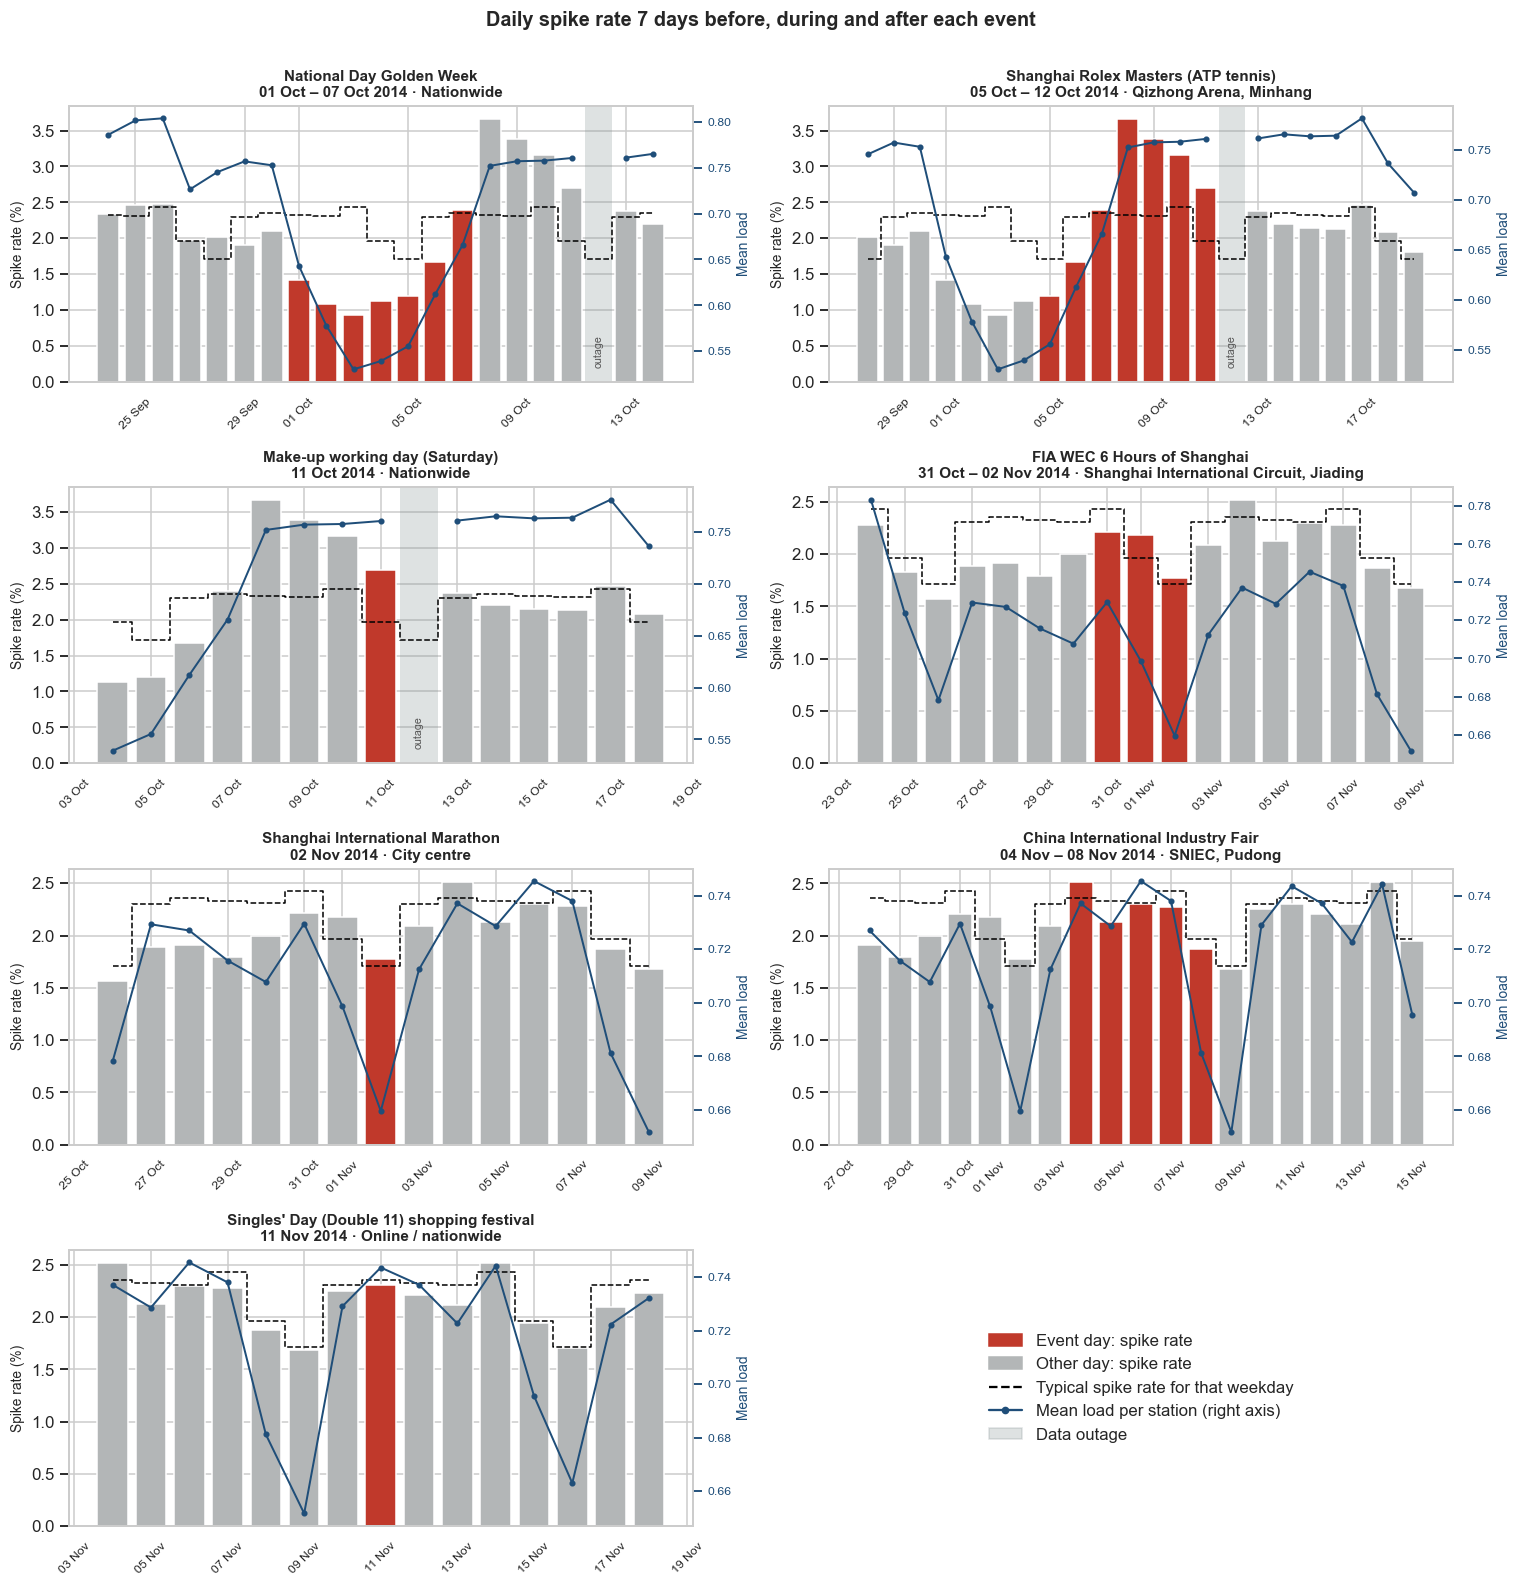

,Dates,Type,Spike rate before (%),Spike rate during (%),Spike rate after (%),During vs before (%),Load before,Load during,Load after
Event,,,,,,,,,
National Day Golden Week,01 Oct – 07 Oct,Public holiday,2.18,1.41,2.91,-35.6,0.768,0.589,0.759
Shanghai Rolex Masters (ATP tennis),05 Oct – 12 Oct,Special event,1.51,2.60,2.17,+71.5,0.649,0.694,0.754
Make-up working day (Saturday),11 Oct,Adjusted working day,2.37,2.70,2.24,+13.7,0.663,0.761,0.762
FIA WEC 6 Hours of Shanghai,31 Oct – 02 Nov,Special event,1.90,2.06,2.12,+8.4,0.724,0.696,0.714
Shanghai International Marathon,02 Nov,Special event,1.94,1.78,2.12,-8.3,0.712,0.660,0.714
China International Industry Fair,04 Nov – 08 Nov,Special event,1.99,2.22,2.15,+11.2,0.707,0.726,0.718
Singles' Day (Double 11) shopping festival,11 Nov,Special event,2.15,2.31,2.12,+7.5,0.716,0.744,0.717


In [37]:
EVENT_WINDOW = 7    # days shown before and after each event

# =============================================================================
# Daily network-wide spike rate and load (days with outage hours are left blank)
# =============================================================================
hourly_spike = spike.mean(axis=1) * 100
valid_hours  = hourly_spike.resample('D').count()
day_rate = hourly_spike.resample('D').mean().where(valid_hours >= 20)
day_load = load.mean(axis=1).resample('D').mean().where(valid_hours >= 20)

# Typical rate per weekday, from days without a holiday, make-up working day or event
event_days = set()
for first, last, *_ in EVENTS:
    event_days |= set(pd.date_range(first, last, freq='D'))
special_days = event_days | set(HOLIDAYS) | set(ADJUSTED_WORKDAYS)
ordinary = day_rate[~day_rate.index.isin(special_days)]
typical_by_weekday = ordinary.groupby(ordinary.index.dayofweek).median()

# =============================================================================
# Small multiples: one panel per event
# =============================================================================
n_cols = 2
n_rows = int(np.ceil((len(EVENTS) + 1) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows))
axes = axes.ravel()
summary_rows = []

for ax, (first, last, name, kind, location) in zip(axes, EVENTS):
    first, last = pd.Timestamp(first), pd.Timestamp(last)
    start, end = first - pd.Timedelta(days=EVENT_WINDOW), last + pd.Timedelta(days=EVENT_WINDOW)
    rate, ld = day_rate[start:end], day_load[start:end]
    during = (rate.index >= first) & (rate.index <= last)

    ax.bar(rate.index, rate.values, width=0.8, color=np.where(during, ACCENT, '#b3b6b7'))
    ax.plot(rate.index, typical_by_weekday.reindex(rate.index.dayofweek).to_numpy(),
            color='black', ls='--', lw=1, drawstyle='steps-mid')
    for d in rate.index[rate.isna()]:
        ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12), color='#7f8c8d', alpha=0.25, lw=0)
        ax.text(d, 0.2, 'outage', rotation=90, ha='center', va='bottom', fontsize=7, color='#555555')

    ax2 = ax.twinx()
    ax2.plot(ld.index, ld.values, color=COLOR, lw=1.3, marker='o', ms=3)
    ax2.set_ylabel('Mean load', color=COLOR, fontsize=9)
    ax2.tick_params(axis='y', colors=COLOR, labelsize=8)
    ax2.grid(False)

    period = first.strftime('%d %b') + ('' if first == last else ' – ' + last.strftime('%d %b'))
    ax.set_title(f'{name}\n{period} 2014 · {location}', fontsize=10)
    ax.set_ylabel('Spike rate (%)', fontsize=9)
    ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', labelsize=8, rotation=45)

    before = day_rate[start:first - pd.Timedelta(days=1)]
    after  = day_rate[last + pd.Timedelta(days=1):end]
    summary_rows.append({
        'Event': name, 'Dates': period, 'Type': kind,
        'Spike rate before (%)': before.mean(), 'Spike rate during (%)': rate[during].mean(),
        'Spike rate after (%)': after.mean(),
        'During vs before (%)': (rate[during].mean() / before.mean() - 1) * 100,
        'Load before': day_load[start:first - pd.Timedelta(days=1)].mean(),
        'Load during': ld[during].mean(),
        'Load after': day_load[last + pd.Timedelta(days=1):end].mean(),
    })

# Legend in the spare panel
for ax in axes[len(EVENTS):]:
    ax.axis('off')
legend_ax = axes[len(EVENTS)]
legend_ax.legend(
    [plt.Rectangle((0, 0), 1, 1, color=ACCENT), plt.Rectangle((0, 0), 1, 1, color='#b3b6b7'),
     plt.Line2D([], [], color='black', ls='--'), plt.Line2D([], [], color=COLOR, marker='o', ms=4),
     plt.Rectangle((0, 0), 1, 1, color='#7f8c8d', alpha=0.25)],
    ['Event day: spike rate', 'Other day: spike rate', 'Typical spike rate for that weekday',
     'Mean load per station (right axis)', 'Data outage'],
    loc='center', fontsize=11, frameon=False)
fig.suptitle(f'Daily spike rate {EVENT_WINDOW} days before, during and after each event',
             fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

event_summary = pd.DataFrame(summary_rows).set_index('Event')
display(event_summary.style
        .format({'Spike rate before (%)': '{:.2f}', 'Spike rate during (%)': '{:.2f}', 'Spike rate after (%)': '{:.2f}',
                 'During vs before (%)': '{:+.1f}', 'Load before': '{:.3f}', 'Load during': '{:.3f}', 'Load after': '{:.3f}'})
        .background_gradient(subset=['During vs before (%)'], cmap='RdBu_r', vmin=-50, vmax=50)
        .set_caption(f'Table 34. Spike rate and load {EVENT_WINDOW} days before, during and after each event'))